In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import importlib
import matplotlib.pyplot as plt
import torch
import plotly.express as plotly
from datetime import datetime
from sklearn.preprocessing import MaxAbsScaler

In [3]:
path_rawdata    = 'F://TFG//datasets/raw_datasets//'
path_train      = 'F://TFG//datasets//data_train//'
path_footdata   ='F:\\TFG\\datasets\\football-data\\'
path_graphs = 'F://TFG//graphs//'
path_eda = path_graphs + 'eda//'

In [ ]:
dateparse = lambda x: datetime.strptime(x, '%Y-%m-%d')
dateparse2 = lambda x: datetime.strptime(x, '%d/%m/%Y')

# data = pd.read_csv(path_rawdata+'historical.csv',sep=';'.decimal='.'.index_col='matchId') 
data = pd.read_csv(path_rawdata+'historical_goals.csv'.sep=';'.decimal='.'.index_col='matchId'.parse_dates=['Date'].date_parser=dateparse) 
fdata_allseasons = pd.read_csv(path_rawdata+'fdata_allseasons.csv'.sep=';')

c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\IPython\core\interactiveshell.py:3165: DtypeWarning: Columns (11) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


In [4]:
str_season = { s:str(s).zfill(4) for s in data.season.unique()}
str_season20 = {k:f'20{s[:2]}-{s[2:]}' for k.s in str_season.items() if not s.startswith('9')}
str_season19 = {k:f'19{s[:2]}-{s[2:]}' for k.s in str_season.items() if s.startswith('9')}
str_season = {**str_season19.**str_season20}
str_season

{9394: '1993-94',
 9495: '1994-95',
 9596: '1995-96',
 9697: '1996-97',
 9798: '1997-98',
 9899: '1998-99',
 9900: '1999-00',
 1: '2000-01',
 102: '2001-02',
 203: '2002-03',
 405: '2004-05',
 607: '2006-07',
 708: '2007-08',
 809: '2008-09',
 910: '2009-10',
 1011: '2010-11',
 1112: '2011-12',
 1213: '2012-13',
 1314: '2013-14',
 1415: '2014-15',
 1516: '2015-16',
 1617: '2016-17',
 1718: '2017-18',
 1819: '2018-19',
 1920: '2019-20',
 2021: '2020-21',
 304: '2003-04',
 506: '2005-06'}

##### Time Series: distribucion de victorias y empates

In [48]:
results = data[["Div"."Date","HomeTeam","AwayTeam","FTR","season"]]
results['season'] = results.season.map(str_season)
results.sort_values('Date')

<ipython-input-48-57301156f310>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Div,Date,HomeTeam,AwayTeam,FTR,season
matchId,,,,,,
27633,D1,1993-08-07,M'Gladbach,Ein Frankfurt,2,1993-94
27627,D1,1993-08-07,Bayern Munich,Freiburg,1,1993-94
27628,D1,1993-08-07,Dortmund,Karlsruhe,1,1993-94
27629,D1,1993-08-07,Duisburg,Leverkusen,0,1993-94
27630,D1,1993-08-07,FC Koln,Kaiserslautern,2,1993-94
...,...,...,...,...,...,...
18309,SP1,2021-05-23,Granada,Getafe,0,2020-21
18310,SP1,2021-05-23,Sevilla,Alaves,1,2020-21
48331,F1,2021-05-23,Rennes,Nimes,1,2020-21


In [49]:
results_grouped = results.groupby(['Div','season','FTR']).Date.count().reset_index()

aux = results_grouped.groupby(['Div','season']).Date.sum().to_frame()
aux.columns = ['Total']
results_grouped = results_grouped.set_index(['Div','season']).join(aux)
results_grouped['Perc'] = results_grouped.Date * 100 / results_grouped.Total
results_grouped = results_grouped.reset_index()
results_grouped

,Div,season,FTR,Date,Total,Perc
0,D1,1993-94,0,83,306,27.124183
1,D1,1993-94,1,152,306,49.673203
2,D1,1993-94,2,71,306,23.202614
3,D1,1994-95,0,86,306,28.104575
4,D1,1994-95,1,147,306,48.039216
...,...,...,...,...,...,...
376,SP1,2019-20,1,174,380,45.789474
377,SP1,2019-20,2,101,380,26.578947
378,SP1,2020-21,0,109,380,28.684211
379,SP1,2020-21,1,158,380,41.578947


D1
0 0 2
I1
0 2 4
SP1
0 4 6
E0
1 0 2
F1
1 2 4


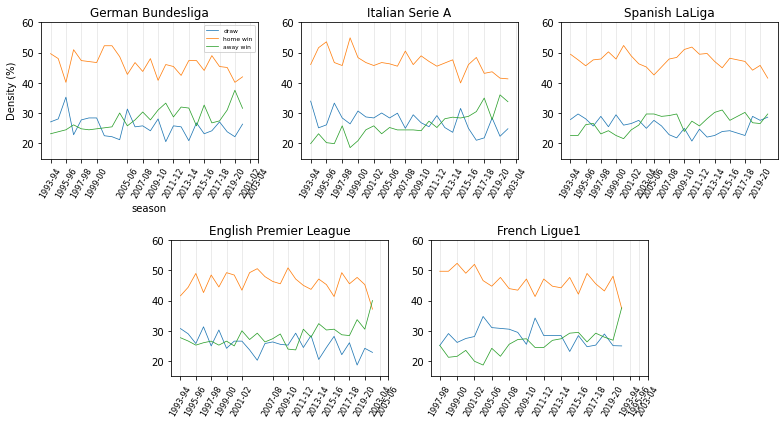

In [50]:
import matplotlib.gridspec as gridspec

gs = gridspec.GridSpec(2,6)
f = plt.figure(figsize=(11,6))
dict_res = {0:'draw',1:'home win',2:'away win'}
season_list = sorted(results_grouped.season.unique())
results_grouped = results_grouped.sort_values('season')

dict_league = {'E0':'English Premier League', 'D1':'German Bundesliga', 'SP1':'Spanish LaLiga', 'F1':'French Ligue1', 'I1':'Italian Serie A'}
# plt.suptitle('Results time series in every league',fontsize=20)

for i,league in enumerate(results_grouped.Div.unique()):
    print(league)
    print(int(i/3),(i%3)*2,(i%3)*2+2)
    j = 0 if i<3 else 1
    ax = plt.subplot(gs[int(i/3), (i%3)*2+j:(i%3)*2+2+j])
    for res in [0,1,2]:
        mask = (results_grouped.Div==league) & (results_grouped.FTR==res)
        sns.lineplot(data=results_grouped[mask],x='season',y='Perc',linewidth=.75,label=dict_res[res],legend=None)
        if i==0: 
            ax.legend(prop={'size':6})
            ax.set_ylabel("Density (%)")
        else: 
            ax.set_ylabel("")
            ax.set_xlabel("")

    ax.set_xticks(ticks=season_list[::2])
    ax.set_xticklabels(labels=season_list[::2],rotation=60,fontsize=8)

    ax.set_title(f'{dict_league[league]}')
    ax.grid(axis='x',alpha=.3)
    ax.set_ylim(15,60)

plt.tight_layout()
# plt.savefig(path_eda+'timeseries_results_leagues.jpg',format='jpg', dpi=200, bbox_inches='tight')

##### Distribution: goles en cada liga

In [5]:
goles = data[['Div', 'season','Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG']]
goles['goals'] = goles.FTHG + goles.FTAG
goles

<ipython-input-5-672eec8b573f>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  goles['goals'] = goles.FTHG + goles.FTAG


,Div,season,Date,HomeTeam,AwayTeam,FTHG,FTAG,goals
matchId,,,,,,,,
0,E0,1,2000-08-19,Charlton,Man City,4.0,0.0,4.0
1,E0,1,2000-08-19,Chelsea,West Ham,4.0,2.0,6.0
2,E0,1,2000-08-19,Coventry,Middlesbrough,1.0,3.0,4.0
3,E0,1,2000-08-19,Derby,Southampton,2.0,2.0,4.0
4,E0,1,2000-08-19,Leeds,Everton,2.0,0.0,2.0
...,...,...,...,...,...,...,...,...
49493,F1,9900,2000-05-13,Nancy,Auxerre,2.0,0.0,2.0
49494,F1,9900,2000-05-13,Rennes,Metz,2.0,0.0,2.0
49495,F1,9900,2000-05-13,Sedan,Marseille,2.0,2.0,4.0


In [6]:
# get the match round

data_aux = data.reset_index()[['matchId','Div','HomeTeam','AwayTeam','Date','season']].melt(['matchId','Div','Date','season'])
data_round = data_aux.sort_values('Date',ascending=True).groupby(['Div','season','value']).Date.rank()

data_aux['rank'] = data_round
round_dict = data_aux[['matchId','rank']].set_index('matchId').to_dict()
goles["round"] = goles.index.map(round_dict['rank'])
goles

<ipython-input-6-66e3e46bb713>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  goles["round"] = goles.index.map(round_dict['rank'])


,Div,season,Date,HomeTeam,AwayTeam,FTHG,FTAG,goals,round
matchId,,,,,,,,,
0,E0,1,2000-08-19,Charlton,Man City,4.0,0.0,4.0,1.0
1,E0,1,2000-08-19,Chelsea,West Ham,4.0,2.0,6.0,1.0
2,E0,1,2000-08-19,Coventry,Middlesbrough,1.0,3.0,4.0,1.0
3,E0,1,2000-08-19,Derby,Southampton,2.0,2.0,4.0,1.0
4,E0,1,2000-08-19,Leeds,Everton,2.0,0.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...
49493,F1,9900,2000-05-13,Nancy,Auxerre,2.0,0.0,2.0,34.0
49494,F1,9900,2000-05-13,Rennes,Metz,2.0,0.0,2.0,34.0
49495,F1,9900,2000-05-13,Sedan,Marseille,2.0,2.0,4.0,34.0


In [7]:
goles_cum = goles.sort_values('round').groupby(['Div','season']).expanding().agg({"goals":"sum", "round":"max"})
goles_cum = goles_cum.groupby(['Div','season','round']).max()
goles_cum = goles_cum.reset_index()
goles_cum

,Div,season,round,goals
0,D1,1,1.0,27.0
1,D1,1,2.0,62.0
2,D1,1,3.0,87.0
3,D1,1,4.0,106.0
4,D1,1,5.0,135.0
...,...,...,...,...
4657,SP1,9900,34.0,898.0
4658,SP1,9900,35.0,926.0
4659,SP1,9900,36.0,955.0
4660,SP1,9900,37.0,974.0


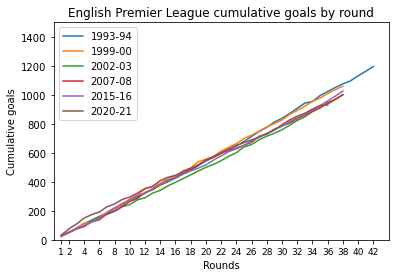

In [9]:
for temp,strtemp in zip([9394, 9900, 203,708,1516,2021],['1993-94','1999-00','2002-03','2007-08','2015-16','2020-21']):
    mask = (goles_cum.Div=='E0') & (goles_cum.season == temp)
    goles_cum[mask].groupby('round').goals.sum().plot(label=strtemp)
plt.legend()
plt.xlabel('Rounds'), plt.ylabel('Cumulative goals')
plt.xticks([1,*np.arange(2,44,2)],fontsize=9)
plt.xlim(0,44), plt.ylim(0,1500)
plt.title('English Premier League cumulative goals by round')
plt.savefig(path_eda+'timeseries_rounds_goals.jpg',format='jpg', dpi=200, bbox_inches='tight')

In [55]:
goles.Date.max()

Timestamp('2021-05-23 00:00:00')

In [56]:
goles

,Div,season,Date,HomeTeam,AwayTeam,FTHG,FTAG,goals,round
matchId,,,,,,,,,
0,E0,1,2000-08-19,Charlton,Man City,4.0,0.0,4.0,1.0
1,E0,1,2000-08-19,Chelsea,West Ham,4.0,2.0,6.0,1.0
2,E0,1,2000-08-19,Coventry,Middlesbrough,1.0,3.0,4.0,1.0
3,E0,1,2000-08-19,Derby,Southampton,2.0,2.0,4.0,1.0
4,E0,1,2000-08-19,Leeds,Everton,2.0,0.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...
49493,F1,9900,2000-05-13,Nancy,Auxerre,2.0,0.0,2.0,34.0
49494,F1,9900,2000-05-13,Rennes,Metz,2.0,0.0,2.0,34.0
49495,F1,9900,2000-05-13,Sedan,Marseille,2.0,2.0,4.0,34.0


In [57]:
goles

,Div,season,Date,HomeTeam,AwayTeam,FTHG,FTAG,goals,round
matchId,,,,,,,,,
0,E0,1,2000-08-19,Charlton,Man City,4.0,0.0,4.0,1.0
1,E0,1,2000-08-19,Chelsea,West Ham,4.0,2.0,6.0,1.0
2,E0,1,2000-08-19,Coventry,Middlesbrough,1.0,3.0,4.0,1.0
3,E0,1,2000-08-19,Derby,Southampton,2.0,2.0,4.0,1.0
4,E0,1,2000-08-19,Leeds,Everton,2.0,0.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...
49493,F1,9900,2000-05-13,Nancy,Auxerre,2.0,0.0,2.0,34.0
49494,F1,9900,2000-05-13,Rennes,Metz,2.0,0.0,2.0,34.0
49495,F1,9900,2000-05-13,Sedan,Marseille,2.0,2.0,4.0,34.0


##### Time Series: evolucion de puntos (y) de los equipos por temporada (x).

Queremos ver que ligas estan mas igualadas y regulares.

In [58]:
puntos = data.reset_index()[["Div","matchId","HomeTeam",'AwayTeam',"FTR","season","Date"]]
# puntos = puntos[puntos.Div=='E0']
puntos = puntos.melt(['matchId','season','Date','Div','FTR'],['HomeTeam','AwayTeam'])
get_puntos = lambda x: {0:1, 1:3, 2:0}[puntos.loc[x].FTR] if puntos.loc[x].variable=="HomeTeam" else {0:1, 1:0, 2:3}[puntos.loc[x].FTR]
puntos["puntos"] = puntos.index.map(get_puntos)
puntos = puntos.drop(columns='FTR').sort_values('Date')
puntos.columns = ['matchId','season','Date','Div','side','team','puntos']
puntos['season'] = puntos.season.map(str_season)
puntos

,matchId,season,Date,Div,side,team,puntos
26234,27627,1993-94,1993-08-07,D1,HomeTeam,Bayern Munich,3
71625,27635,1993-94,1993-08-07,D1,AwayTeam,Stuttgart,0
71624,27634,1993-94,1993-08-07,D1,AwayTeam,Schalke 04,0
71623,27633,1993-94,1993-08-07,D1,AwayTeam,Ein Frankfurt,3
71622,27632,1993-94,1993-08-07,D1,AwayTeam,Dresden,1
...,...,...,...,...,...,...,...
89841,48327,2020-21,2021-05-23,F1,AwayTeam,Nice,3
89842,48328,2020-21,2021-05-23,F1,AwayTeam,Marseille,1
89843,48329,2020-21,2021-05-23,F1,AwayTeam,Montpellier,3
44455,48324,2020-21,2021-05-23,F1,HomeTeam,Angers,0


In [59]:
puntos_grouped = puntos.groupby(['team','season','Div']).puntos.sum().reset_index().sort_values(['team','season'])
puntos_grouped

,team,season,Div,puntos
0,Aachen,2007-08,D1,34
1,Ajaccio,2004-05,F1,45
2,Ajaccio,2005-06,F1,33
3,Ajaccio,2011-12,F1,41
4,Ajaccio,2012-13,F1,42
...,...,...,...,...
2461,Zaragoza,2007-08,SP1,42
2462,Zaragoza,2009-10,SP1,41
2463,Zaragoza,2010-11,SP1,45
2464,Zaragoza,2011-12,SP1,43


In [60]:
puntos_grouped['rank'] = puntos_grouped[['season','Div','puntos']].groupby(['season','Div']).puntos.rank(method='first',ascending=False)
puntos_grouped

,team,season,Div,puntos,rank
0,Aachen,2007-08,D1,34,16.0
1,Ajaccio,2004-05,F1,45,14.0
2,Ajaccio,2005-06,F1,33,18.0
3,Ajaccio,2011-12,F1,41,15.0
4,Ajaccio,2012-13,F1,42,15.0
...,...,...,...,...,...
2461,Zaragoza,2007-08,SP1,42,18.0
2462,Zaragoza,2009-10,SP1,41,14.0
2463,Zaragoza,2010-11,SP1,45,15.0
2464,Zaragoza,2011-12,SP1,43,16.0


In [61]:
teams = puntos_grouped.team.unique()
teamseasons = pd.DataFrame({'team':teams,'season':[season_list]*len(teams)})
teamseasons = teamseasons.explode('season').reset_index().set_index(['team','season'])
puntos_exploded = teamseasons.merge(puntos_grouped[['team','season','rank']],left_index=True,right_on=['team','season'],how='left')
puntos_exploded = puntos_exploded.merge(puntos_grouped[['team','Div']].drop_duplicates(),left_on='team',right_on='team',how='left')
puntos_exploded

,index,team,season,rank,Div
0,0,Aachen,1993-94,NaN,D1
1,0,Aachen,1994-95,NaN,D1
2,0,Aachen,1995-96,NaN,D1
3,0,Aachen,1996-97,NaN,D1
4,0,Aachen,1997-98,NaN,D1
...,...,...,...,...,...
6547,233,Zaragoza,2016-17,NaN,SP1
6548,233,Zaragoza,2017-18,NaN,SP1
6549,233,Zaragoza,2018-19,NaN,SP1
6550,233,Zaragoza,2019-20,NaN,SP1


In [62]:
puntos_exploded[puntos_exploded.team=='Sociedad']

,index,team,season,rank,Div
5320,190,Sociedad,1993-94,13.0,SP1
5321,190,Sociedad,1994-95,11.0,SP1
5322,190,Sociedad,1995-96,7.0,SP1
5323,190,Sociedad,1996-97,8.0,SP1
5324,190,Sociedad,1997-98,4.0,SP1
5325,190,Sociedad,1998-99,10.0,SP1
5326,190,Sociedad,1999-00,14.0,SP1
5327,190,Sociedad,2000-01,13.0,SP1
5328,190,Sociedad,2001-02,14.0,SP1
5329,190,Sociedad,2002-03,2.0,SP1


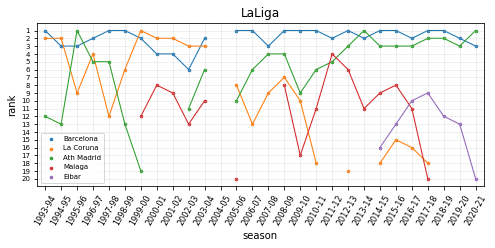

In [63]:
plt.figure(figsize=(8,3))
maskaux = puntos_exploded.Div=='SP1'
colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink','tab:gray','tab:olive','tab:cyan']
teams = ['Barcelona','La Coruna','Ath Madrid','Malaga','Eibar']
# teams = puntos_exploded[maskaux].team.unique()[:5]
handles = []
for c,team in zip(colors,teams):
    mask = maskaux & (puntos_exploded.team==team)
    plaliga = sns.pointplot(data=puntos_exploded[mask],x='season',y='rank',hue='team',scale=.4,palette=dict(zip(teams,colors)))
plt.yticks(ticks=np.arange(1,21),labels=np.arange(1,21),fontsize=7)
plt.xticks(rotation=60,fontsize=8)
plt.title('LaLiga')
plt.gca().invert_yaxis()
plt.legend(prop={'size':7})
plt.grid(alpha=.25)
# plt.savefig(path_eda+'timeseries_rank_laliga.jpg',format='jpg', dpi=200, bbox_inches='tight')

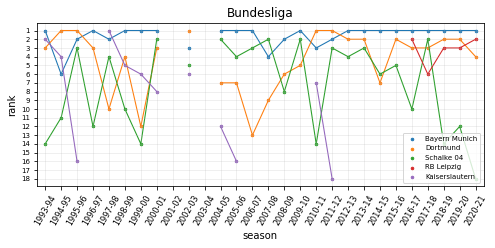

In [64]:
plt.figure(figsize=(8,3))
maskaux = puntos_exploded.Div=='D1'
colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink','tab:gray','tab:olive','tab:cyan']
teams = ['Bayern Munich','Dortmund','Schalke 04','RB Leipzig','Kaiserslautern']
# teams = puntos_exploded[maskaux].team.unique()[:5]
handles = []
for c,team in zip(colors,teams):
    mask = maskaux & (puntos_exploded.team==team)
    pbundes = sns.pointplot(data=puntos_exploded[mask],x='season',y='rank',hue='team',scale=.4,palette=dict(zip(teams,colors)))
plt.yticks(ticks=np.arange(1,19),labels=np.arange(1,19),fontsize=7)
plt.xticks(rotation=60,fontsize=8)
plt.title('Bundesliga')
plt.gca().invert_yaxis()
plt.legend(prop={'size':7})
plt.grid(alpha=.25)
# plt.savefig(path_eda+'timeseries_rank_bundesliga.jpg',format='jpg', dpi=200, bbox_inches='tight')

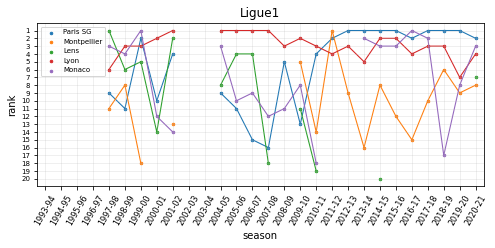

In [65]:
plt.figure(figsize=(8,3))
maskaux = puntos_exploded.Div=='F1'
colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink','tab:gray','tab:olive','tab:cyan']
teams = ['Paris SG','Montpellier','Lens','Lyon','Monaco']
# teams = puntos_exploded[maskaux].team.unique()[:5]
handles = []
for c,team in zip(colors,teams):
    mask = maskaux & (puntos_exploded.team==team)
    plig1 = sns.pointplot(data=puntos_exploded[mask],x='season',y='rank',hue='team',scale=.4,palette=dict(zip(teams,colors)))
plt.yticks(ticks=np.arange(1,21),labels=np.arange(1,21),fontsize=7)
plt.xticks(rotation=60,fontsize=8)
plt.title('Ligue1')
plt.gca().invert_yaxis()
plt.legend(prop={'size':7})
plt.grid(alpha=.25)
# plt.savefig(path_eda+'timeseries_rank_ligue1.jpg',format='jpg', dpi=200, bbox_inches='tight')

##### Scatter plot: style of playing given passes and faults

In [66]:
data = pd.read_csv(path_rawdata+'historical.csv',sep=';',decimal=',',index_col='matchId',parse_dates=['Date'],date_parser=dateparse) 
data = data[['season','Date','Div','HomeTeam', 'AwayTeam','HS', 'AS','HF', 'AF','FTR']].reset_index()
data['season'] = data.season.map(str_season)
data

,matchId,season,Date,Div,HomeTeam,AwayTeam,HS,AS,HF,AF,FTR
0,0,2000-01,2000-08-19,E0,Charlton,Man City,17.0,8.0,13.0,12.0,1
1,1,2000-01,2000-08-19,E0,Chelsea,West Ham,17.0,12.0,19.0,14.0,1
2,2,2000-01,2000-08-19,E0,Coventry,Middlesbrough,6.0,16.0,15.0,21.0,2
3,3,2000-01,2000-08-19,E0,Derby,Southampton,6.0,13.0,11.0,13.0,0
4,4,2000-01,2000-08-19,E0,Leeds,Everton,17.0,12.0,21.0,20.0,1
...,...,...,...,...,...,...,...,...,...,...,...
29706,48329,2020-21,2021-05-23,F1,Nantes,Montpellier,15.0,8.0,8.0,11.0,2
29707,48330,2020-21,2021-05-23,F1,Reims,Bordeaux,10.0,12.0,11.0,6.0,2
29708,48331,2020-21,2021-05-23,F1,Rennes,Nimes,13.0,9.0,11.0,10.0,1
29709,48332,2020-21,2021-05-23,F1,St Etienne,Dijon,19.0,10.0,13.0,10.0,2


In [67]:
key_cols = ['matchId','season','Date','Div']
melt_side = data.melt(key_cols,['HomeTeam','AwayTeam'],var_name='side',value_name='team').drop(['side'],axis=1)
melt_shots = data.melt(key_cols,['HS','AS'],var_name='side',value_name='shots').drop([*key_cols,'side'],axis=1)
melt_fouls = data.melt(key_cols,['HF','AF'],var_name='side',value_name='faults').drop([*key_cols,'side'],axis=1)

assert len(melt_side) == len(melt_shots) == len(melt_fouls) 
style = pd.concat([melt_side,melt_shots,melt_fouls],axis=1)
style

,matchId,season,Date,Div,team,shots,faults
0,0,2000-01,2000-08-19,E0,Charlton,17.0,13.0
1,1,2000-01,2000-08-19,E0,Chelsea,17.0,19.0
2,2,2000-01,2000-08-19,E0,Coventry,6.0,15.0
3,3,2000-01,2000-08-19,E0,Derby,6.0,11.0
4,4,2000-01,2000-08-19,E0,Leeds,17.0,21.0
...,...,...,...,...,...,...,...
59417,48329,2020-21,2021-05-23,F1,Montpellier,8.0,11.0
59418,48330,2020-21,2021-05-23,F1,Bordeaux,12.0,6.0
59419,48331,2020-21,2021-05-23,F1,Nimes,9.0,10.0
59420,48332,2020-21,2021-05-23,F1,Dijon,10.0,10.0


In [68]:
# style = style.merge(puntos_grouped.reset_index()[['matchId','team','rank']],on=['matchId','team'])
# style

In [69]:
style_grouped = style.groupby(['Div','season','team']).agg({'shots':'sum','faults':'sum'}).reset_index()
style_grouped = style_grouped.merge(puntos_grouped,on=['Div','season','team'])
style_grouped

,Div,season,team,shots,faults,puntos,rank
0,D1,2000-01,Bayern Munich,498.0,545.0,63,1.0
1,D1,2000-01,Bochum,367.0,554.0,27,18.0
2,D1,2000-01,Cottbus,369.0,626.0,39,14.0
3,D1,2000-01,Dortmund,516.0,599.0,58,3.0
4,D1,2000-01,Ein Frankfurt,350.0,561.0,35,16.0
...,...,...,...,...,...,...,...
1601,SP1,2020-21,Sevilla,461.0,492.0,77,4.0
1602,SP1,2020-21,Sociedad,428.0,566.0,62,5.0
1603,SP1,2020-21,Valencia,396.0,459.0,43,13.0
1604,SP1,2020-21,Valladolid,367.0,510.0,31,19.0


In [70]:
quantiles = style_grouped['rank'].quantile([.2,.4,.7]).to_numpy()
print(quantiles)
cluster = lambda x: np.sum(quantiles>x)

cluster(15)

[ 4.  8. 14.]


0

In [71]:
style_grouped['cluster'] = style_grouped['rank'].map(cluster)
style_grouped.sort_values(['puntos'],ascending=False)

,Div,season,team,shots,faults,puntos,rank,cluster
1134,I1,2013-14,Juventus,602.0,566.0,102,1.0,3
1417,SP1,2011-12,Real Madrid,729.0,526.0,100,1.0,3
1428,SP1,2012-13,Barcelona,524.0,401.0,100,1.0,3
616,E0,2017-18,Man City,664.0,344.0,100,1.0,3
1369,SP1,2009-10,Barcelona,594.0,513.0,99,1.0,3
...,...,...,...,...,...,...,...,...
635,E0,2018-19,Huddersfield,400.0,420.0,16,20.0,0
381,E0,2004-05,Sunderland,337.0,538.0,15,20.0,0
945,F1,2019-20,Toulouse,317.0,396.0,13,20.0,0
301,D1,2020-21,Schalke 04,287.0,396.0,13,18.0,0


In [72]:
cluster_data = style_grouped[['season','team','cluster','rank']]

In [73]:
data = pd.read_csv(path_rawdata+'historical.csv',sep=';',decimal=',',index_col='matchId',parse_dates=['Date'],date_parser=dateparse) 
data = data[['season','Date','Div','HomeTeam', 'AwayTeam','HS', 'AS','HF', 'AF','FTR']].reset_index()
data['season'] = data.season.map(str_season)

key_cols = ['matchId','season','Date','Div']
melt_side = data.melt(key_cols,['HomeTeam','AwayTeam'],var_name='side',value_name='team')
melt_shots = data.melt(key_cols,['HS','AS'],var_name='side',value_name='shots').drop([*key_cols,'side'],axis=1)
melt_fouls = data.melt(key_cols,['HF','AF'],var_name='side',value_name='faults').drop([*key_cols,'side'],axis=1)

assert len(melt_side) == len(melt_shots) == len(melt_fouls) 
style = pd.concat([melt_side,melt_shots,melt_fouls],axis=1)
data_melted = style.merge(cluster_data,on=['season','team'])
data_melted

,matchId,season,Date,Div,side,team,shots,faults,cluster,rank
0,0,2000-01,2000-08-19,E0,HomeTeam,Charlton,17.0,13.0,1,9.0
1,33,2000-01,2000-09-06,E0,HomeTeam,Charlton,8.0,14.0,1,9.0
2,51,2000-01,2000-09-16,E0,HomeTeam,Charlton,9.0,8.0,1,9.0
3,70,2000-01,2000-09-30,E0,HomeTeam,Charlton,12.0,8.0,1,9.0
4,90,2000-01,2000-10-21,E0,HomeTeam,Charlton,5.0,11.0,1,9.0
...,...,...,...,...,...,...,...,...,...,...
59417,48246,2020-21,2021-03-20,F1,AwayTeam,Marseille,7.0,16.0,2,5.0
59418,48266,2020-21,2021-04-10,F1,AwayTeam,Marseille,13.0,12.0,2,5.0
59419,48284,2020-21,2021-04-23,F1,AwayTeam,Marseille,11.0,2.0,2,5.0
59420,48307,2020-21,2021-05-09,F1,AwayTeam,Marseille,15.0,12.0,2,5.0


In [74]:
data_pivoted = data_melted.pivot(index=['matchId','season','Date','Div'],columns='side',values=['team','shots','faults','cluster']).reset_index()
data_pivoted = data_pivoted.merge(data[['matchId','FTR']],on='matchId')
data_pivoted.columns = ['matchId','drop','season','Date','Div','AwayTeam','HomeTeam','shots_A','shots_H','faults_A','faults_H','cluster_A','cluster_H','FTR']
data_pivoted = data_pivoted.drop('drop',axis=1)
data_pivoted

c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\pandas\core\reshape\merge.py:648: UserWarning:

merging between different levels can give an unintended result (2 levels on the left,1 on the right)



,matchId,season,Date,Div,AwayTeam,HomeTeam,shots_A,shots_H,faults_A,faults_H,cluster_A,cluster_H,FTR
0,0,2000-01,2000-08-19,E0,Man City,Charlton,8.0,17.0,12.0,13.0,0,1,1
1,1,2000-01,2000-08-19,E0,West Ham,Chelsea,12.0,17.0,14.0,19.0,0,2,1
2,2,2000-01,2000-08-19,E0,Middlesbrough,Coventry,16.0,6.0,21.0,15.0,0,0,2
3,3,2000-01,2000-08-19,E0,Southampton,Derby,13.0,6.0,13.0,11.0,1,0,0
4,4,2000-01,2000-08-19,E0,Everton,Leeds,12.0,17.0,20.0,21.0,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29706,2576334,2017-18,2018-05-19,I1,Verona,Juventus,9.0,26.0,11.0,13.0,0,3,1
29707,2576335,2017-18,2018-05-20,I1,Inter,Lazio,15.0,14.0,13.0,12.0,2,2,2
29708,2576336,2017-18,2018-05-20,I1,Roma,Sassuolo,15.0,16.0,8.0,14.0,3,1,2
29709,2576337,2017-18,2018-05-20,I1,Sampdoria,Spal,9.0,16.0,11.0,10.0,1,0,1


In [75]:
# sorpresas del local
data_local = data_pivoted[data_pivoted.FTR==1]
mask_clusters = (data_local.cluster_A - data_local.cluster_H) > 1
data_local_obvious = data_local[mask_clusters]
data_local_obvious

,matchId,season,Date,Div,AwayTeam,HomeTeam,shots_A,shots_H,faults_A,faults_H,cluster_A,cluster_H,FTR
11,11,2000-01,2000-08-22,E0,Chelsea,Bradford,14.0,12.0,16.0,14.0,2,0,1
15,15,2000-01,2000-08-23,E0,Sunderland,Man City,9.0,15.0,14.0,24.0,2,0,1
131,131,2000-01,2000-11-18,E0,Arsenal,Everton,4.0,4.0,12.0,20.0,3,0,1
137,137,2000-01,2000-11-19,E0,Liverpool,Tottenham,9.0,6.0,13.0,11.0,3,1,1
142,142,2000-01,2000-11-25,E0,Chelsea,Everton,10.0,11.0,18.0,11.0,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29440,2576068,2017-18,2017-10-29,I1,Atalanta,Udinese,7.0,7.0,15.0,15.0,2,0,1
29457,2576085,2017-18,2017-11-19,I1,Juventus,Sampdoria,19.0,9.0,15.0,12.0,3,1,1
29496,2576124,2017-18,2017-12-17,I1,Milan,Verona,30.0,6.0,13.0,12.0,2,0,1
29677,2576305,2017-18,2018-04-29,I1,Napoli,Fiorentina,4.0,28.0,10.0,17.0,3,1,1


In [76]:
data_local = data_pivoted[data_pivoted.FTR==1]
mask_clusters = (data_local.cluster_H - data_local.cluster_A) > 1
data_local_underdog = data_local[mask_clusters]
data_local_underdog

,matchId,season,Date,Div,AwayTeam,HomeTeam,shots_A,shots_H,faults_A,faults_H,cluster_A,cluster_H,FTR
1,1,2000-01,2000-08-19,E0,West Ham,Chelsea,12.0,17.0,14.0,19.0,0,2,1
4,4,2000-01,2000-08-19,E0,Everton,Leeds,12.0,17.0,20.0,21.0,0,2,1
6,6,2000-01,2000-08-19,E0,Bradford,Liverpool,3.0,16.0,8.0,8.0,0,3,1
9,9,2000-01,2000-08-20,E0,Newcastle,Man United,9.0,19.0,13.0,7.0,1,3,1
19,19,2000-01,2000-08-26,E0,Charlton,Arsenal,7.0,18.0,15.0,12.0,1,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29672,2576300,2017-18,2018-04-28,I1,Chievo,Roma,12.0,15.0,10.0,12.0,1,3,1
29683,2576311,2017-18,2018-05-05,I1,Bologna,Juventus,6.0,15.0,13.0,12.0,0,3,1
29686,2576314,2017-18,2018-05-05,I1,Verona,Milan,8.0,17.0,10.0,9.0,0,2,1
29704,2576332,2017-18,2018-05-20,I1,Crotone,Napoli,9.0,19.0,9.0,3.0,0,3,1


In [77]:
data_season_faults = data_melted.groupby(['season','team']).faults.mean()
data_season_faults.name = 'season_faults'
data_season_faults

season   team         
2000-01  Arsenal          13.026316
         Aston Villa      12.921053
         Bayern Munich    16.029412
         Bochum           16.294118
         Bradford         13.605263
                            ...    
2020-21  Werder Bremen    11.156250
         West Brom        10.771429
         West Ham         10.085714
         Wolfsburg        12.875000
         Wolves           11.114286
Name: season_faults, Length: 1606, dtype: float64

In [78]:
data_melted = data_melted.merge(data_season_faults,left_on=['season','team'],right_index=True)
data_melted

,matchId,season,Date,Div,side,team,shots,faults,cluster,rank,season_faults
0,0,2000-01,2000-08-19,E0,HomeTeam,Charlton,17.0,13.0,1,9.0,12.289474
1,33,2000-01,2000-09-06,E0,HomeTeam,Charlton,8.0,14.0,1,9.0,12.289474
2,51,2000-01,2000-09-16,E0,HomeTeam,Charlton,9.0,8.0,1,9.0,12.289474
3,70,2000-01,2000-09-30,E0,HomeTeam,Charlton,12.0,8.0,1,9.0,12.289474
4,90,2000-01,2000-10-21,E0,HomeTeam,Charlton,5.0,11.0,1,9.0,12.289474
...,...,...,...,...,...,...,...,...,...,...,...
59417,48246,2020-21,2021-03-20,F1,AwayTeam,Marseille,7.0,16.0,2,5.0,13.131579
59418,48266,2020-21,2021-04-10,F1,AwayTeam,Marseille,13.0,12.0,2,5.0,13.131579
59419,48284,2020-21,2021-04-23,F1,AwayTeam,Marseille,11.0,2.0,2,5.0,13.131579
59420,48307,2020-21,2021-05-09,F1,AwayTeam,Marseille,15.0,12.0,2,5.0,13.131579


In [79]:
mask_bcn = (data_pivoted.AwayTeam=='Barcelona') | (data_pivoted.HomeTeam=='Barcelona')
data_pivoted_bcn = data_pivoted[mask_bcn].sort_values('Date')

def gana_o_pierde_bcn(d,team):
    return lambda r: {0:0, 1:1, 2:0}[d.loc[r].FTR] if d.loc[r].HomeTeam==team else {0:1, 1:0, 2:1}[d.loc[r].FTR]

data_pivoted_bcn['res_bcn'] = data_pivoted_bcn.index.map(gana_o_pierde_bcn(data_pivoted_bcn,'Barcelona'))
data_pivoted_bcn

,matchId,season,Date,Div,AwayTeam,HomeTeam,shots_A,shots_H,faults_A,faults_H,cluster_A,cluster_H,FTR,res_bcn
6892,12231,2005-06,2005-08-27,SP1,Barcelona,Alaves,17.0,5.0,19.0,17.0,3,0,0,1
6905,12244,2005-06,2005-09-11,SP1,Mallorca,Barcelona,6.0,23.0,20.0,13.0,1,3,1,1
6916,12255,2005-06,2005-09-18,SP1,Barcelona,Ath Madrid,18.0,16.0,17.0,22.0,3,1,1,0
6922,12261,2005-06,2005-09-21,SP1,Valencia,Barcelona,5.0,10.0,25.0,30.0,3,3,0,0
6933,12272,2005-06,2005-09-24,SP1,Barcelona,Betis,23.0,9.0,17.0,19.0,3,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12633,18269,2020-21,2021-05-02,SP1,Barcelona,Valencia,14.0,9.0,14.0,12.0,3,1,2,1
12637,18273,2020-21,2021-05-08,SP1,Ath Madrid,Barcelona,11.0,12.0,26.0,13.0,3,3,0,0
12647,18283,2020-21,2021-05-11,SP1,Barcelona,Levante,17.0,16.0,4.0,12.0,3,0,0,1
12658,18294,2020-21,2021-05-16,SP1,Celta,Barcelona,4.0,20.0,14.0,9.0,1,3,2,0


In [80]:
key_cols = ['matchId','season','Date','Div']
bcn_nogana = data_pivoted_bcn[[*key_cols,'res_bcn']].merge(data_melted,on=key_cols,how='left')
bcn_nogana['_size_plot'] = [3]*len(bcn_nogana)
bcn_nogana

,matchId,season,Date,Div,res_bcn,side,team,shots,faults,cluster,rank,season_faults,_size_plot
0,12231,2005-06,2005-08-27,SP1,1,HomeTeam,Alaves,5.0,17.0,0,18.0,18.342105,3
1,12231,2005-06,2005-08-27,SP1,1,AwayTeam,Barcelona,17.0,19.0,3,1.0,16.815789,3
2,12244,2005-06,2005-09-11,SP1,1,AwayTeam,Mallorca,6.0,20.0,1,13.0,19.815789,3
3,12244,2005-06,2005-09-11,SP1,1,HomeTeam,Barcelona,23.0,13.0,3,1.0,16.815789,3
4,12255,2005-06,2005-09-18,SP1,0,HomeTeam,Ath Madrid,16.0,22.0,1,10.0,20.921053,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1211,18283,2020-21,2021-05-11,SP1,1,HomeTeam,Levante,16.0,12.0,0,14.0,13.394737,3
1212,18294,2020-21,2021-05-16,SP1,0,AwayTeam,Celta,4.0,14.0,1,8.0,16.605263,3
1213,18294,2020-21,2021-05-16,SP1,0,HomeTeam,Barcelona,20.0,9.0,3,3.0,9.394737,3
1214,18303,2020-21,2021-05-22,SP1,1,HomeTeam,Eibar,17.0,11.0,0,20.0,13.000000,3


In [81]:
# partidos que pierde o empata el barcelona
dataplot = bcn_nogana[(bcn_nogana.res_bcn==0) & (bcn_nogana.team !='Barcelona')]
fig = plotly.scatter( 
                    dataplot,
                    x='shots',
                    y='faults',
                    color='cluster',
                    hover_name='team',
                    hover_data=['season','rank']
                )
fig.update_traces(marker={'size': 15, 'opacity': .75})

c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\pandas\core\indexing.py:1597: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



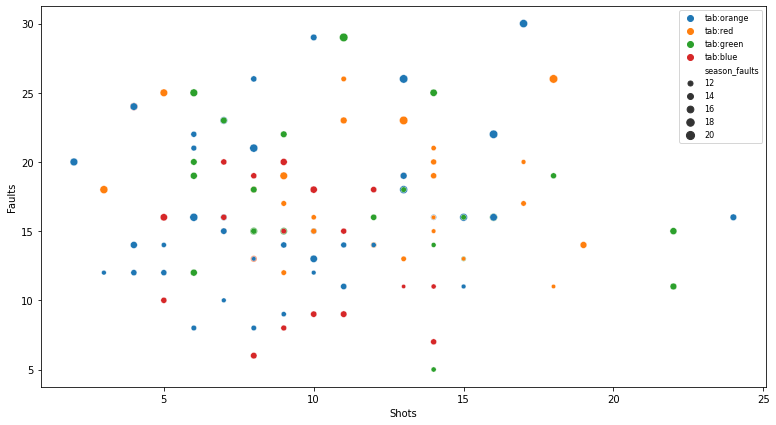

In [82]:
plt.figure(figsize=(13,7))

colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink','tab:gray','tab:olive','tab:cyan']
dataplot.loc[:,'_color_plot'] = dataplot.cluster.map(dict(zip(sorted(dataplot.cluster.unique()), colors)))
dataplot.loc[:,'_label_plot'] = dataplot.cluster.map(dict(zip(sorted(dataplot.cluster.unique()), ['14º-20º','8º-13º','4º-7º','1º-3º'])))

p = sns.scatterplot(data=dataplot,x='shots',y='faults',hue='_color_plot',size='season_faults',label='_label_plot')

# handles, labels = p.get_legend_handles_labels()
leg = plt.legend(prop={'size':8})

plt.xlabel('Shots'), plt.ylabel('Faults')
plt.show()

In [92]:
# partidos que pierde o empata el barcelona
dataplot = bcn_nogana[(bcn_nogana.res_bcn==0) & (bcn_nogana.team !='Barcelona')]
dataplot.loc[:,'_sizeref'] = dataplot["season_faults"]**3 / 20
dataplot.loc[:,'Position:'] = dataplot.cluster.map(dict(zip(sorted(dataplot.cluster.unique()), ['14º-20º','8º-13º','4º-7º','1º-3º'])))
dataplot = dataplot.sort_values('cluster')

fig = plotly.scatter( 
                    dataplot,
                    x='shots',
                    y='faults',
                    size='_sizeref',
                    size_max=20,
                    color='Position:',
                    hover_name='team',
                    hover_data=['season','rank','season_faults']
                )
# fig.update_traces(marker={'size': 15, 'opacity': .75})
fig.update_layout(
    autosize=False,
    width=1000,
    height=600,)

fig.show()
# fig.write_image(path_eda+'scatter_shots_faults_bcnnogana.jpeg',scale=3)

c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\pandas\core\indexing.py:1597: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\pandas\core\indexing.py:1676: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



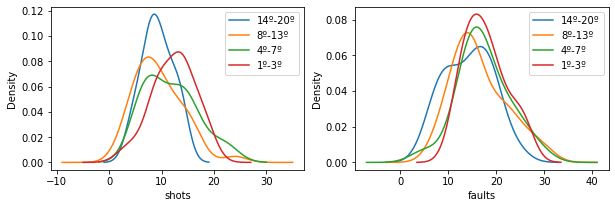

In [108]:
fig = plt.figure(figsize=(10,3))

fig.add_subplot(1,2,1)
ft = 'shots'
for p in dataplot['Position:'].unique():
    mask = dataplot['Position:']==p
    dataplot[mask][ft].plot(kind='kde',label=p)
plt.xlabel(ft)
plt.legend()

fig.add_subplot(1,2,2)
ft = 'faults'
for p in dataplot['Position:'].unique():
    mask = dataplot['Position:']==p
    dataplot[mask][ft].plot(kind='kde',label=p)
plt.xlabel(ft)
plt.legend()

fig.savefig(path_eda+'dist_shots_faults_bcnnogana.jpg',format='jpg', dpi=200, bbox_inches='tight')

##### Distribution: faults depending the ranking

In [125]:
spanish_faults = data_melted[data_melted.Div=='SP1'].sort_values('rank')
spanish_faults['rank_bin'] = pd.cut(spanish_faults['rank'],[0,4,8,15,20], labels=['1º - 3º','4º - 7º','8º - 14º','15º - 20º'])
spanish_faults 

,matchId,season,Date,Div,side,team,shots,faults,cluster,rank,season_faults,rank_bin
15926,13131,2007-08,2007-12-08,SP1,AwayTeam,Real Madrid,15.0,21.0,3,1.0,16.105263,1º - 3º
21381,15856,2014-15,2015-02-01,SP1,HomeTeam,Barcelona,19.0,10.0,3,1.0,9.710526,1º - 3º
21382,15876,2014-15,2015-02-15,SP1,HomeTeam,Barcelona,18.0,6.0,3,1.0,9.710526,1º - 3º
21383,15883,2014-15,2015-02-21,SP1,HomeTeam,Barcelona,11.0,9.0,3,1.0,9.710526,1º - 3º
21384,15907,2014-15,2015-03-08,SP1,HomeTeam,Barcelona,19.0,13.0,3,1.0,9.710526,1º - 3º
...,...,...,...,...,...,...,...,...,...,...,...,...
21755,15724,2014-15,2014-10-18,SP1,HomeTeam,Cordoba,8.0,16.0,0,20.0,13.000000,15º - 20º
21756,15733,2014-15,2014-10-25,SP1,HomeTeam,Cordoba,7.0,13.0,0,20.0,13.000000,15º - 20º
21757,15751,2014-15,2014-11-07,SP1,HomeTeam,Cordoba,14.0,10.0,0,20.0,13.000000,15º - 20º
25798,18303,2020-21,2021-05-22,SP1,HomeTeam,Eibar,17.0,11.0,0,20.0,13.000000,15º - 20º


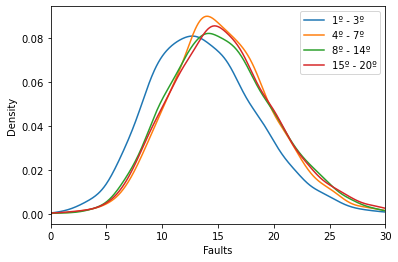

In [134]:
for rank in spanish_faults['rank_bin'].unique():
    mask = spanish_faults['rank_bin']==rank
    spanish_faults[mask].faults.plot(kind='kde',label=rank)

plt.legend()
plt.xlim(0,30)
plt.xlabel('Faults')
plt.savefig(path_eda+'dist_faults_rank_laliga.jpg',format='jpg', dpi=200, bbox_inches='tight')

##### Time Series: evolucion estilo de juego del Atalanta

In [11]:
def formatDate(strdate):
    try: date = datetime.strptime(strdate, "%d/%m/%y").date()
    except: date = datetime.strptime(strdate, "%d/%m/%Y").date()
    return date

In [6]:
data = pd.read_csv(path_rawdata+'fdata_allseasons.csv',sep=';',decimal=',')
data['matchId'] = data.index
mask = data.Date.isna() == False
data = data[mask]
data['season'] = data.season.map(str_season)
data['Date']   = data.Date.apply(formatDate)
data

c:\Users\GuillemUPV\Anaconda3\envs\tfg\lib\site-packages\IPython\core\interactiveshell.py:3165: DtypeWarning: Columns (10,11,16,17,22,23) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HF,AF,HO,AO,HY,AY,HR,AR,season,matchId
0,E0,2000-08-19,Charlton,Man City,4.0,0.0,H,2.0,0.0,H,...,13.0,12.0,8.0,6.0,1.0,2.0,0.0,0.0,2000-01,0
1,E0,2000-08-19,Chelsea,West Ham,4.0,2.0,H,1.0,0.0,H,...,19.0,14.0,2.0,3.0,1.0,2.0,0.0,0.0,2000-01,1
2,E0,2000-08-19,Coventry,Middlesbrough,1.0,3.0,A,1.0,1.0,D,...,15.0,21.0,1.0,3.0,5.0,3.0,1.0,0.0,2000-01,2
3,E0,2000-08-19,Derby,Southampton,2.0,2.0,D,1.0,2.0,A,...,11.0,13.0,0.0,2.0,1.0,1.0,0.0,0.0,2000-01,3
4,E0,2000-08-19,Leeds,Everton,2.0,0.0,H,2.0,0.0,H,...,21.0,20.0,6.0,1.0,1.0,3.0,0.0,0.0,2000-01,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49493,F1,2000-05-13,Nancy,Auxerre,2.0,0.0,H,0.0,0.0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999-00,49493
49494,F1,2000-05-13,Rennes,Metz,2.0,0.0,H,0.0,0.0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999-00,49494
49495,F1,2000-05-13,Sedan,Marseille,2.0,2.0,D,1.0,1.0,D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999-00,49495
49496,F1,2000-05-13,St Etienne,Monaco,3.0,1.0,H,3.0,1.0,H,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1999-00,49496


In [19]:
def melt_columns(df: pd.DataFrame, id_cols: list, pairs: list, names: list) -> pd.DataFrame:
    res = pd.concat([df[id_cols],df[id_cols]],axis=0,ignore_index=True)
    res.columns = id_cols
    print(res.columns)
    for n,p in zip(names,pairs):
        df_melted = df.melt(id_cols,value_vars=p,var_name='side',value_name=n).drop([*id_cols,'side'],axis=1)
        res = pd.concat([res,df_melted],axis=1)
        res.columns = [*res.columns[:-1],n]
    print(res.columns)
    return res

In [8]:
timeseries_cols = ['scored','received','faults','yellowcards']

data_melted = melt_columns(
                data.reset_index(),
                id_cols=['matchId','season','Date','Div'],
                pairs=[('HomeTeam','AwayTeam'),('FTHG','FTAG'),('FTAG','FTHG'),('HF','AF'),('HY','AY')], 
                names=['team',*timeseries_cols]
            )

data_melted

Index(['matchId', 'season', 'Date', 'Div'], dtype='object')


,matchId,season,Date,Div,team,scored,received,faults,yellowcards
0,0,2000-01,2000-08-19,E0,Charlton,4.0,0.0,13.0,1.0
1,1,2000-01,2000-08-19,E0,Chelsea,4.0,2.0,19.0,1.0
2,2,2000-01,2000-08-19,E0,Coventry,1.0,3.0,15.0,5.0
3,3,2000-01,2000-08-19,E0,Derby,2.0,2.0,11.0,1.0
4,4,2000-01,2000-08-19,E0,Leeds,2.0,0.0,21.0,1.0
...,...,...,...,...,...,...,...,...,...
90761,49493,1999-00,2000-05-13,F1,Auxerre,0.0,2.0,NaN,NaN
90762,49494,1999-00,2000-05-13,F1,Metz,0.0,2.0,NaN,NaN
90763,49495,1999-00,2000-05-13,F1,Marseille,2.0,2.0,NaN,NaN
90764,49496,1999-00,2000-05-13,F1,Monaco,1.0,3.0,NaN,NaN


In [12]:
mask = data_melted.team=='Atalanta'
data_atalanta = data_melted[mask].sort_values('Date')
data_atalanta

mask = data_melted.team=='Getafe'
data_getafe = data_melted[mask].sort_values('Date')
data_getafe

mask = data_melted.team=='Schalke 04'
data_juve = data_melted[mask].sort_values('Date')
data_juve

,matchId,season,Date,Div,team,scored,received,faults,yellowcards
71624,27634,1993-94,1993-08-07,D1,Schalke 04,0.0,3.0,NaN,NaN
26250,27643,1993-94,1993-08-14,D1,Schalke 04,1.0,0.0,NaN,NaN
71640,27650,1993-94,1993-08-21,D1,Schalke 04,1.0,4.0,NaN,NaN
26268,27661,1993-94,1993-08-28,D1,Schalke 04,1.0,2.0,NaN,NaN
71659,27669,1993-94,1993-09-01,D1,Schalke 04,2.0,3.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
26195,27588,2020-21,2021-04-11,D1,Schalke 04,1.0,0.0,10.0,0.0
71583,27593,2020-21,2021-04-17,D1,Schalke 04,0.0,4.0,12.0,1.0
71591,27601,2020-21,2021-04-20,D1,Schalke 04,0.0,1.0,12.0,5.0
71609,27619,2020-21,2021-05-08,D1,Schalke 04,2.0,4.0,12.0,2.0


In [13]:
def window_columns(df: pd.DataFrame, cols: list, n: str):
    for c in cols:
        df[f'{c}_{n}'] = df.rolling(window=n,on='Date',min_periods=15,center=True)[c].mean()
    return df    

In [14]:
# windowing atalanta games
n = 38
mask_yellowcards = data_atalanta.yellowcards.isnull() == False
data_atalanta = window_columns(data_atalanta,cols=timeseries_cols,n=n)[mask_yellowcards]
data_atalanta

data_getafe = window_columns(data_getafe,cols=timeseries_cols,n=n)
data_getafe

mask_yellowcards = data_juve.yellowcards.isnull() == False
data_juve = window_columns(data_juve,cols=timeseries_cols,n=n)[mask_yellowcards]
data_juve

,matchId,season,Date,Div,team,scored,received,faults,yellowcards,scored_38,received_38,faults_38,yellowcards_38
20446,21839,2000-01,2000-08-13,D1,Schalke 04,2.0,1.0,15.0,2.0,1.578947,1.157895,17.052632,2.052632
65838,21848,2000-01,2000-08-20,D1,Schalke 04,4.0,0.0,10.0,3.0,1.605263,1.263158,17.400000,2.000000
20459,21852,2000-01,2000-09-05,D1,Schalke 04,3.0,0.0,16.0,0.0,1.657895,1.236842,17.666667,2.000000
65850,21860,2000-01,2000-09-09,D1,Schalke 04,1.0,1.0,10.0,3.0,1.631579,1.263158,17.727273,2.000000
20482,21875,2000-01,2000-09-17,D1,Schalke 04,1.0,1.0,23.0,2.0,1.552632,1.236842,17.739130,2.086957
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26195,27588,2020-21,2021-04-11,D1,Schalke 04,1.0,0.0,10.0,0.0,0.666667,2.416667,12.333333,2.208333
71583,27593,2020-21,2021-04-17,D1,Schalke 04,0.0,4.0,12.0,1.0,0.652174,2.347826,12.260870,2.173913
71591,27601,2020-21,2021-04-20,D1,Schalke 04,0.0,1.0,12.0,5.0,0.681818,2.318182,12.045455,2.181818
71609,27619,2020-21,2021-05-08,D1,Schalke 04,2.0,4.0,12.0,2.0,0.619048,2.333333,12.000000,2.095238


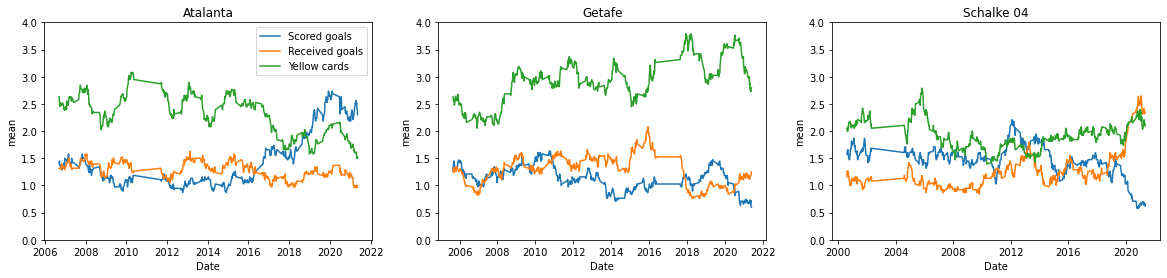

In [15]:
plt.figure(figsize=(20,4))

ax = plt.subplot(1,3,1)
ax.set_ylim(0,4)
ax.set_title('Atalanta')
ax.set_ylabel('mean')
sns.lineplot(data=data_atalanta,x='Date',y=f'scored_{n}',label='Scored goals')
sns.lineplot(data=data_atalanta,x='Date',y=f'received_{n}',label='Received goals')
sns.lineplot(data=data_atalanta,x='Date',y=f'yellowcards_{n}',label='Yellow cards')

ax = plt.subplot(1,3,2)
ax.set_ylim(0,4)
ax.set_ylabel('mean')
ax.set_title('Getafe')
sns.lineplot(data=data_getafe,x='Date',y=f'scored_{n}')
sns.lineplot(data=data_getafe,x='Date',y=f'received_{n}')
sns.lineplot(data=data_getafe,x='Date',y=f'yellowcards_{n}')

ax = plt.subplot(1,3,3)
ax.set_ylim(0,4)
ax.set_ylabel('mean')
ax.set_title('Schalke 04')
sns.lineplot(data=data_juve,x='Date',y=f'scored_{n}')
sns.lineplot(data=data_juve,x='Date',y=f'received_{n}')
sns.lineplot(data=data_juve,x='Date',y=f'yellowcards_{n}')

plt.savefig(path_eda+'timeseries_goals_faults_3teams.jpg',format='jpg', dpi=200, bbox_inches='tight')

### DATASET ANALYSIS

##### Derby Features

In [68]:
data = pd.read_csv(path_rawdata+'historical_goals_longterm.csv',sep=';',decimal=',')
data['matchId'] = data.index
mask = data.Date.isna() == False
data = data[mask]
data['season'] = data.season.map(str_season)
data['Date']   = data.Date.apply(lambda d: datetime.strptime(d, "%Y-%m-%d").date())
data['FTR'] = data.FTR.map({0:'Draw',1:'Home win',2:'Away win'})
data

,aux,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,season,IdH,...,derby_points_5_home,derby_Scored_5_away,derby_Side_5_away,derby_points_5_away,derby_Scored_10_home,derby_Side_10_home,derby_points_10_home,derby_Scored_10_away,derby_Side_10_away,derby_points_10_away
0,0,E0,2000-08-19,Charlton,Man City,4.0,0.0,Home win,2000-01,4000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,E0,2000-08-19,Chelsea,West Ham,4.0,2.0,Home win,2000-01,1610,...,1.00,7.0,0.0,1.6,9.0,7.0,1.142857,9.0,0.0,1.571429
2,2,E0,2000-08-19,Coventry,Middlesbrough,1.0,3.0,Away win,2000-01,4001,...,0.00,10.0,0.0,3.0,1.0,4.0,0.000000,10.0,0.0,3.000000
3,3,E0,2000-08-19,Derby,Southampton,2.0,2.0,Draw,2000-01,4002,...,1.75,6.0,0.0,1.0,7.0,4.0,1.750000,6.0,0.0,1.000000
4,4,E0,2000-08-19,Leeds,Everton,2.0,0.0,Home win,2000-01,4003,...,0.60,8.0,0.0,1.8,5.0,7.0,0.571429,12.0,0.0,1.857143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45378,49493,F1,2000-05-13,Nancy,Auxerre,2.0,0.0,Home win,1999-00,4123,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45379,49494,F1,2000-05-13,Rennes,Metz,2.0,0.0,Home win,1999-00,3774,...,2.00,2.0,2.0,0.5,3.0,0.0,2.000000,2.0,2.0,0.500000
45380,49495,F1,2000-05-13,Sedan,Marseille,2.0,2.0,Draw,1999-00,4116,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45381,49496,F1,2000-05-13,St Etienne,Monaco,3.0,1.0,Home win,1999-00,3782,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
derby_cols = [ col for col in data.columns if 'derby' in col ]
data['Dif_goals'] = np.abs(data.FTHG - data.FTAG)
derby_cols = ['matchId','Div','Date','season','HomeTeam','AwayTeam','FTR','Dif_goals',*derby_cols]
derby_data = data[derby_cols]
derby_data = derby_data.round(2)
# derby_data.loc[:,'FTR'] = derby_data.FTR.apply(lambda r: str(r))
derby_data

,matchId,Div,Date,season,HomeTeam,AwayTeam,FTR,Dif_goals,derby_Scored_1_home,derby_Side_1_home,...,derby_points_5_home,derby_Scored_5_away,derby_Side_5_away,derby_points_5_away,derby_Scored_10_home,derby_Side_10_home,derby_points_10_home,derby_Scored_10_away,derby_Side_10_away,derby_points_10_away
0,0,E0,2000-08-19,2000-01,Charlton,Man City,Home win,4.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,E0,2000-08-19,2000-01,Chelsea,West Ham,Home win,2.0,0.0,1.0,...,1.00,7.0,0.0,1.6,9.0,7.0,1.14,9.0,0.0,1.57
2,2,E0,2000-08-19,2000-01,Coventry,Middlesbrough,Away win,2.0,0.0,1.0,...,0.00,10.0,0.0,3.0,1.0,4.0,0.00,10.0,0.0,3.00
3,3,E0,2000-08-19,2000-01,Derby,Southampton,Draw,0.0,3.0,1.0,...,1.75,6.0,0.0,1.0,7.0,4.0,1.75,6.0,0.0,1.00
4,4,E0,2000-08-19,2000-01,Leeds,Everton,Home win,2.0,4.0,1.0,...,0.60,8.0,0.0,1.8,5.0,7.0,0.57,12.0,0.0,1.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45378,45378,F1,2000-05-13,1999-00,Nancy,Auxerre,Home win,2.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45379,45379,F1,2000-05-13,1999-00,Rennes,Metz,Home win,2.0,1.0,0.0,...,2.00,2.0,2.0,0.5,3.0,0.0,2.00,2.0,2.0,0.50
45380,45380,F1,2000-05-13,1999-00,Sedan,Marseille,Draw,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45381,45381,F1,2000-05-13,1999-00,St Etienne,Monaco,Home win,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [86]:
bins = 7

bins_labesl = np.linspace(0,3,bins)
bins_labesl2 = [*bins_labesl[1:],""]
labels = list(map(lambda x: ' - '.join([str(x[0]),str(x[1])]),(zip(bins_labesl,bins_labesl2))))

In [87]:
def bin_column(col, bins ,labels):
    assert len(labels) == bins
    return pd.cut(col,bins=bins,labels=labels)

derby_data['derby_points_10_home'] = bin_column(derby_data.derby_points_10_home, bins, labels)
derby_data['derby_points_3_home'] = bin_column(derby_data.derby_points_3_home, bins, labels)
derby_data['derby_points_5_home'] = bin_column(derby_data.derby_points_5_home, bins, labels)
derby_data.derby_points_10_home

0              NaN
1        1.0 - 1.5
2        0.0 - 0.5
3        2.0 - 2.5
4        0.5 - 1.0
           ...    
45378          NaN
45379    2.0 - 2.5
45380          NaN
45381          NaN
45382          NaN
Name: derby_points_10_home, Length: 45383, dtype: category
Categories (7, object): ['0.0 - 0.5' < '0.5 - 1.0' < '1.0 - 1.5' < '1.5 - 2.0' < '2.0 - 2.5' < '2.5 - 3.0' < '3.0 - ']

In [88]:
# mask = derby_data.Div=='D1'
mask_date = derby_data.Date>datetime.strptime("01-07-2018","%d-%m-%Y").date()
dataplot = derby_data[mask & mask_date]

In [89]:
cols_x, cols_y = 'derby_points_3_home', 'derby_points_10_home'
dataplot = derby_data[mask & mask_date]
plotly.scatter(dataplot, x=cols_x, y=cols_y, hover_data=['HomeTeam','AwayTeam','season'], color='FTR', size='Dif_goals')

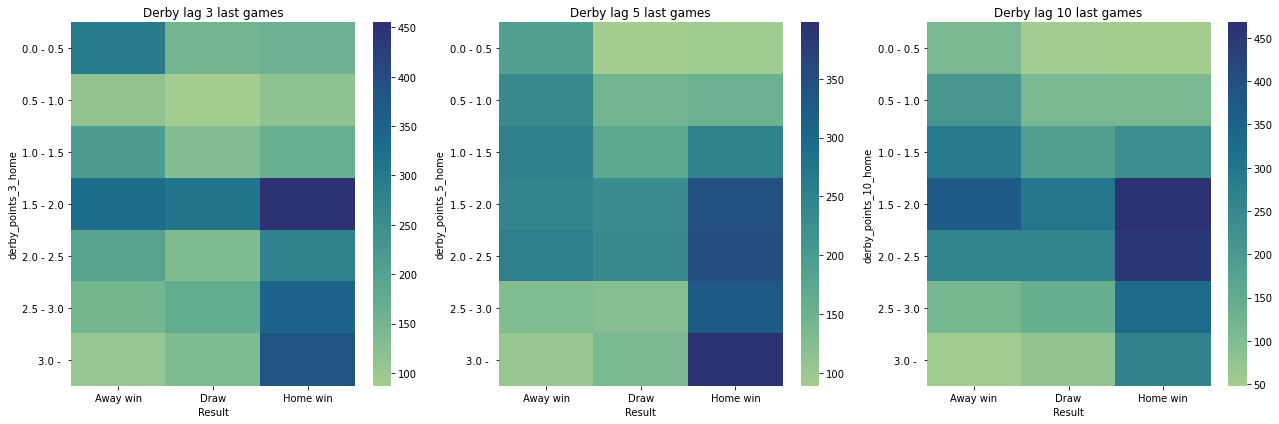

In [100]:
fig = plt.figure(figsize=(18,6))
ax = fig.add_subplot(1,3,1)
d = dataplot.groupby(['derby_points_3_home','FTR']).matchId.count().unstack().fillna(0).astype(int)
sns.heatmap(d,cmap='crest')
ax.set_title('Derby lag 3 last games')
ax.set_xlabel('Result')
ax.set_yticklabels(labels,rotation=0)

ax = fig.add_subplot(1,3,2)
d = dataplot.groupby(['derby_points_5_home','FTR']).matchId.count().unstack().fillna(0).astype(int)
sns.heatmap(d,cmap='crest')
ax.set_title('Derby lag 5 last games')
ax.set_xlabel('Result')
ax.set_yticklabels(labels,rotation=0)

ax = fig.add_subplot(1,3,3)
d = dataplot.groupby(['derby_points_10_home','FTR']).matchId.count().unstack().fillna(0).astype(int)
sns.heatmap(d,cmap='crest')
ax.set_title('Derby lag 10 last games')
ax.set_xlabel('Result')
ax.set_yticklabels(labels,rotation=0)

fig.tight_layout()
fig.savefig(path_eda+'heatmap_derby.jpg',format='jpg', dpi=200, bbox_inches='tight')

##### Time Series: lags of a team

In [25]:
data = pd.read_csv(path_rawdata+'historical_goals_longterm.csv',sep=';',decimal=',')
data['matchId'] = data.index
mask = data.Date.isna() == False
data = data[mask]
data['season'] = data.season.map(str_season)
data['Date']   = data.Date.apply(lambda d: datetime.strptime(d, "%Y-%m-%d").date())
data['FTR'] = data.FTR.map({0:'Draw',1:'Home win',2:'Away win'})
data.shape

(45383, 92)

In [26]:
columns = [col for col in data.columns if ('points' in col) and ('D_' in col)]
key_cols = ['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'season', 'matchId']
data_lags = data[[*key_cols,*columns]]
data_lags.shape, data_lags.columns

((45383, 23),
 Index(['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'season',
        'matchId', 'points_15D_home', 'points_15D_away', 'points_30D_home',
        'points_30D_away', 'points_60D_home', 'points_60D_away',
        'points_180D_home', 'points_180D_away', 'points_365D_home',
        'points_365D_away', 'points_730D_home', 'points_730D_away',
        'points_1825D_home', 'points_1825D_away'],
       dtype='object'))

In [39]:
timeseries_cols = ['current match','15D','30D','60D','180D','365D','730D','1825D']
cols2melt = [('HomeTeam','AwayTeam'),('FTHG','FTAG'),('points_15D_home', 'points_15D_away'),('points_30D_home',
        'points_30D_away'),('points_60D_home', 'points_60D_away'),('points_180D_home', 'points_180D_away'),('points_365D_home',
        'points_365D_away'), ('points_730D_home','points_730D_away'),('points_1825D_home', 'points_1825D_away')]

data_melted = melt_columns(
                data.sort_values('Date'),
                id_cols=['matchId','season','Date','Div'],
                pairs=cols2melt, 
                names=['team',*timeseries_cols]
            )
data_melted.shape

Index(['matchId', 'season', 'Date', 'Div'], dtype='object')
Index(['matchId', 'season', 'Date', 'Div', 'team', 'current match', '15D',
       '30D', '60D', '180D', '365D', '730D', '1825D'],
      dtype='object')


(90766, 13)

In [42]:
data_melted[mask_team]

,matchId,season,Date,Div,team,current match,15D,30D,60D,180D,365D,730D,1825D
99,35352,1993-94,1993-08-29,I1,Atalanta,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
162,35370,1993-94,1993-09-08,I1,Atalanta,2.0,1.500000,1.5,1.500000,NaN,NaN,NaN,NaN
231,35388,1993-94,1993-09-19,I1,Atalanta,0.0,1.000000,1.5,1.500000,NaN,NaN,NaN,NaN
295,35406,1993-94,1993-10-03,I1,Atalanta,1.0,0.500000,0.8,1.166667,NaN,NaN,NaN,NaN
407,35424,1993-94,1993-10-24,I1,Atalanta,1.0,NaN,0.0,0.875000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
90373,35265,2020-21,2021-03-21,I1,Atalanta,2.0,1.500000,2.4,2.000000,1.925926,2.050000,2.053333,1.834225
90474,35291,2020-21,2021-04-11,I1,Atalanta,3.0,NaN,3.0,2.625000,1.884615,2.095238,2.067568,1.850267
90562,35311,2020-21,2021-04-22,I1,Atalanta,1.0,3.000000,3.0,2.666667,2.037037,2.136364,2.094595,1.871658
90640,35329,2020-21,2021-05-02,I1,Atalanta,1.0,2.333333,2.6,2.444444,2.074074,2.130435,2.080000,1.877005


In [82]:
data_melted[data_melted.team=='Malaga']

,matchId,season,Date,Div,team,current match,15D,30D,60D,180D,365D,730D,1825D
9267,20064,1999-00,1999-08-22,SP1,Malaga,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9358,20083,1999-00,1999-09-12,SP1,Malaga,3.0,NaN,1.500000,1.500000,NaN,NaN,NaN,NaN
9446,20099,1999-00,1999-09-25,SP1,Malaga,1.0,1.5,1.000000,1.500000,NaN,NaN,NaN,NaN
9520,20119,1999-00,1999-10-12,SP1,Malaga,3.0,NaN,1.250000,1.333333,NaN,NaN,NaN,NaN
9655,20149,1999-00,1999-10-30,SP1,Malaga,1.0,0.0,0.250000,0.714286,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85049,16380,2017-18,2018-03-18,SP1,Malaga,0.0,0.0,0.000000,0.222222,0.541667,0.846154,0.946667,1.131579
85111,16394,2017-18,2018-04-06,SP1,Malaga,2.0,NaN,1.333333,0.444444,0.695652,0.868421,0.946667,1.136842
85228,16422,2017-18,2018-04-19,SP1,Malaga,0.0,0.0,1.000000,0.500000,0.666667,0.789474,0.933333,1.115183
85321,16441,2017-18,2018-04-30,SP1,Malaga,1.0,1.0,1.200000,0.875000,0.666667,0.710526,0.960000,1.115183


In [96]:
year_month = data_melted.Date.apply(lambda d: 'M'.join([str(d.year),str(d.month).zfill(2)]))
data_melted['year_month'] = year_month
data_melted

,matchId,season,Date,Div,team,current match,15D,30D,60D,180D,365D,730D,1825D,year_month
0,26240,1993-94,1993-08-07,D1,M'Gladbach,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1993M08
1,26234,1993-94,1993-08-07,D1,Bayern Munich,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1993M08
2,26235,1993-94,1993-08-07,D1,Dortmund,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1993M08
3,26236,1993-94,1993-08-07,D1,Duisburg,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1993M08
4,26237,1993-94,1993-08-07,D1,FC Koln,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1993M08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90761,17612,2020-21,2021-05-23,SP1,Getafe,0.0,1.000000,1.20,0.888889,0.892857,0.937500,1.213333,1.357616,2021M05
90762,17613,2020-21,2021-05-23,SP1,Alaves,0.0,2.333333,1.60,1.666667,1.037037,0.937500,1.026667,1.211640,2021M05
90763,44462,2020-21,2021-05-23,F1,Nimes,0.0,1.500000,1.00,0.857143,0.923077,0.945946,0.939394,1.116505,2021M05
90764,44464,2020-21,2021-05-23,F1,Lorient,1.0,1.500000,2.25,1.714286,1.269231,1.108108,NaN,1.026667,2021M05


<ipython-input-110-e03db928824e>:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels=seasons,rotation=45)
<ipython-input-110-e03db928824e>:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels=seasons,rotation=45)
<ipython-input-110-e03db928824e>:14: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(labels=seasons,rotation=45)


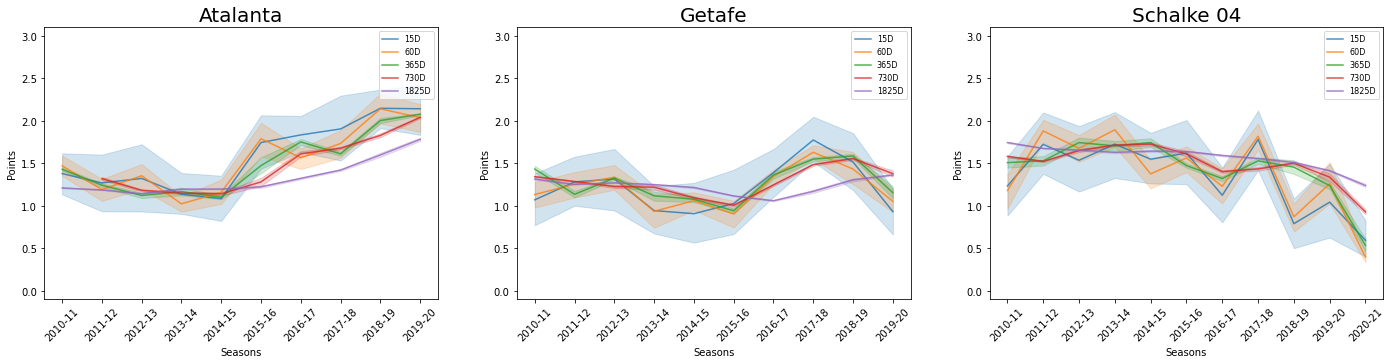

In [110]:
fig = plt.figure(figsize=(24,5))
mask_date = data_melted.Date>datetime.strptime("01-07-2010","%d-%m-%Y").date()
dataplot = data_melted[mask_date]
seasons = dataplot.season.unique()
for i,team in enumerate(['Atalanta','Getafe','Schalke 04']):
    mask_team = dataplot.team==team
    data_team = dataplot[mask_team]
    ax = fig.add_subplot(1,3,i+1)
    ax.set_title(team,fontsize=20)
    for col in ['15D', '60D', '365D', '730D', '1825D']:
        sns.lineplot(data=data_team,x='season',y=col,label=col,linewidth=1.5,alpha=.8)
    ax.legend(prop={'size':8})
    ax.set_xlabel('Seasons')
    ax.set_xticklabels(labels=seasons,rotation=45)
    ax.set_ylim(-0.1,3.1)
    ax.set_ylabel('Points')

fig.savefig(path_eda+'timeseries_lags_historical.jpg',format='jpg', dpi=200, bbox_inches='tight')

In [111]:
# import matplotlib.gridspec as gridspec
# fig = plt.figure(figsize=(10,8))
# mask_date = data_melted.Date>datetime.strptime("01-07-2010","%d-%m-%Y").date()
# dataplot = data_melted[mask_date]
# seasons = dataplot.season.unique()
# gs = gridspec.GridSpec(2,4)
# pos= [0,2,1]
# for i,team in enumerate(['Atalanta','Getafe','Schalke 04']):
#     mask_team = dataplot.team==team
#     data_team = dataplot[mask_team]
#     ax = plt.subplot(gs[int(i/2), pos[i]:(pos[i]+2)])
#     ax.set_title(team,fontsize=20)
#     for col in ['15D', '60D', '365D', '730D', '1825D']:
#         sns.lineplot(data=data_team,x='season',y=col,label=col,linewidth=1.5,alpha=.8)
#     ax.legend(prop={'size':8})
#     ax.set_xlabel('Seasons')
#     ax.set_xticklabels(labels=seasons,rotation=45)
#     ax.set_ylim(-0.1,3.1)
#     ax.set_ylabel('Points')

# fig.tight_layout()
# fig.savefig(path_eda+'timeseries_lags_historical.jpg',format='jpg', dpi=200, bbox_inches='tight')

##### Time Series: lags relationship with result

In [140]:
data = pd.read_csv(path_rawdata+'historical_goals_longterm.csv',sep=';',decimal=',')
data['matchId'] = data.index
mask = data.Date.isna() == False
data = data[mask]
data['season'] = data.season.map(str_season)
data['Date']   = data.Date.apply(lambda d: datetime.strptime(d, "%Y-%m-%d").date())
data['FTR'] = data.FTR.map({0:'Draw',1:'Home win',2:'Away win'})
data

,aux,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,season,IdH,...,derby_points_5_home,derby_Scored_5_away,derby_Side_5_away,derby_points_5_away,derby_Scored_10_home,derby_Side_10_home,derby_points_10_home,derby_Scored_10_away,derby_Side_10_away,derby_points_10_away
0,0,E0,2000-08-19,Charlton,Man City,4.0,0.0,Home win,2000-01,4000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,E0,2000-08-19,Chelsea,West Ham,4.0,2.0,Home win,2000-01,1610,...,1.00,7.0,0.0,1.6,9.0,7.0,1.142857,9.0,0.0,1.571429
2,2,E0,2000-08-19,Coventry,Middlesbrough,1.0,3.0,Away win,2000-01,4001,...,0.00,10.0,0.0,3.0,1.0,4.0,0.000000,10.0,0.0,3.000000
3,3,E0,2000-08-19,Derby,Southampton,2.0,2.0,Draw,2000-01,4002,...,1.75,6.0,0.0,1.0,7.0,4.0,1.750000,6.0,0.0,1.000000
4,4,E0,2000-08-19,Leeds,Everton,2.0,0.0,Home win,2000-01,4003,...,0.60,8.0,0.0,1.8,5.0,7.0,0.571429,12.0,0.0,1.857143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45378,49493,F1,2000-05-13,Nancy,Auxerre,2.0,0.0,Home win,1999-00,4123,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45379,49494,F1,2000-05-13,Rennes,Metz,2.0,0.0,Home win,1999-00,3774,...,2.00,2.0,2.0,0.5,3.0,0.0,2.000000,2.0,2.0,0.500000
45380,49495,F1,2000-05-13,Sedan,Marseille,2.0,2.0,Draw,1999-00,4116,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45381,49496,F1,2000-05-13,St Etienne,Monaco,3.0,1.0,Home win,1999-00,3782,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [141]:
columns = [col for col in data.columns if ('points' in col) and ('D_' in col)]
key_cols = ['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'season', 'matchId']
data_lags = data[[*key_cols,*columns]]
data_lags.shape, data_lags.columns

((45383, 23),
 Index(['Div', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'season',
        'matchId', 'points_15D_home', 'points_15D_away', 'points_30D_home',
        'points_30D_away', 'points_60D_home', 'points_60D_away',
        'points_180D_home', 'points_180D_away', 'points_365D_home',
        'points_365D_away', 'points_730D_home', 'points_730D_away',
        'points_1825D_home', 'points_1825D_away'],
       dtype='object'))

In [142]:
mask_date = data_lags.Date>datetime.strptime("01-07-2010","%d-%m-%Y").date()
mask = True
dataplot = data_lags[mask & mask_date]
dataplot.shape

(19915, 23)

In [148]:
cols2compare = ['points_60D_home','points_60D_away','points_730D_home','points_730D_away']
dataplot = dataplot[[*key_cols,*cols2compare]]
mask_home = (dataplot[cols2compare[0]] > dataplot[cols2compare[2]]) & (dataplot[cols2compare[0]] > 2) & (dataplot[cols2compare[2]] < 1.5)
mask_away = (dataplot[cols2compare[1]] < dataplot[cols2compare[3]]) & (dataplot[cols2compare[3]] > 2)
mask = dataplot[cols2compare[2]] < dataplot[cols2compare[3]]

In [138]:
dataplot_15d = dataplot[mask & mask_home & mask_away]

In [149]:
pd.options.display.max_rows = 68
dataplot_60d = dataplot[mask & mask_home & mask_away]
dataplot_60d

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,season,matchId,points_60D_home,points_60D_away,points_730D_home,points_730D_away
4208,E0,2013-09-01,Liverpool,Man United,1.0,0.0,Home win,2013-14,4208,3.000000,2.000000,1.493333,2.306667
5035,E0,2015-10-24,West Ham,Chelsea,2.0,1.0,Home win,2015-16,5035,2.333333,1.166667,1.246753,2.116883
5099,E0,2015-12-14,Leicester,Chelsea,2.0,1.0,Home win,2015-16,5099,2.428571,1.000000,1.377358,2.026316
5128,E0,2015-12-29,Leicester,Man City,0.0,0.0,Draw,2015-16,5128,2.375000,1.625000,1.410714,2.120000
5882,E0,2017-12-23,Burnley,Tottenham,0.0,3.0,Away win,2017-18,5882,2.111111,1.222222,1.285714,2.051948
6036,E0,2018-04-19,Burnley,Chelsea,1.0,2.0,Away win,2017-18,6036,2.666667,1.166667,1.295775,2.092105
6547,E0,2019-10-19,Crystal Palace,Man City,0.0,2.0,Away win,2019-20,6547,2.166667,2.000000,1.368421,2.526316
6878,E0,2020-10-17,Everton,Liverpool,2.0,2.0,Draw,2020-21,6878,3.000000,2.250000,1.430556,2.569444
6968,E0,2020-12-19,Southampton,Man City,0.0,1.0,Away win,2020-21,6968,2.125000,1.625000,1.430556,2.183099
13808,SP1,2011-05-21,Malaga,Barcelona,1.0,3.0,Away win,2010-11,13808,2.125000,1.875000,1.090909,2.506494


In [135]:
plotly.scatter(dataplot,x='points_365D_home',y='points_30D_home',color='FTR',hover_data=['HomeTeam','AwayTeam','FTHG','FTAG','season'])

In [144]:
for col in columns:
    data_lags[col] = bin_column(data_lags[col],7,labels)

<ipython-input-144-aef97f550aeb>:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



##### Variance Threshold

In [196]:
import mytrain_lib_cluster as ml
import pandas as pd
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

In [197]:
traindata = ml.FootballMatchesDataset(dataset='historical_longterm',file='train')
traindata = pd.DataFrame(data=traindata.data.cpu().numpy(),columns=traindata.features)
traindata

,side_avg_15D_home,Scored_15D_home,Received_15D_home,points_15D_home,Shots_15D_home,Target_15D_home,Corner_15D_home,Faults_15D_home,YellowCards_15D_home,RedCards_15D_home,...,side_avg_1825D_away,Scored_1825D_away,Received_1825D_away,points_1825D_away,Shots_1825D_away,Target_1825D_away,Corner_1825D_away,Faults_1825D_away,YellowCards_1825D_away,RedCards_1825D_away
0,2.0,0.0,3.0,0.0,6.5,2.5,4.5,17.0,4.0,0.0,...,7.0,21.0,27.0,1.133333,11.266667,5.200000,6.666667,12.800000,1.466667,0.866667
1,2.0,2.0,4.0,0.5,8.0,4.5,4.0,18.0,1.5,0.0,...,7.0,14.0,30.0,0.800000,7.866667,3.733333,4.400000,12.800000,1.600000,0.800000
2,2.0,4.0,2.0,3.0,10.5,4.0,5.0,8.5,1.5,0.0,...,7.0,18.0,31.0,0.666667,8.666667,3.866667,4.533333,13.533333,2.200000,1.066667
3,2.0,2.0,4.0,0.0,11.0,6.5,8.0,14.0,2.0,0.0,...,7.0,21.0,21.0,1.400000,9.000000,5.466667,5.866667,12.133333,1.266667,0.666667
4,2.0,4.0,2.0,3.0,9.0,5.5,6.0,14.5,1.5,0.0,...,7.0,19.0,26.0,0.733333,9.133333,4.800000,4.600000,13.133333,2.133333,1.066667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13896,1.0,4.0,2.0,3.0,12.0,5.0,7.5,14.5,4.5,2.5,...,18.0,33.0,83.0,0.567568,12.270270,3.918919,4.351351,13.000000,2.108108,1.162162
13897,1.0,4.0,2.0,2.0,18.0,7.0,8.0,8.0,1.5,0.5,...,37.0,73.0,122.0,0.920000,10.253333,3.480000,3.760000,14.400000,2.040000,0.960000
13898,1.0,3.0,1.0,2.0,11.0,3.0,4.0,12.5,2.0,1.0,...,75.0,174.0,272.0,1.013245,11.364238,3.701987,4.695364,14.218543,2.291391,1.185430
13899,1.0,3.0,3.0,1.0,15.5,4.5,7.5,11.0,3.0,1.5,...,94.0,306.0,202.0,1.656085,15.158730,4.994709,6.883598,13.476190,2.074074,1.031746


In [198]:
old_traindata = traindata.copy()

X_mean = old_traindata.mean(axis=0)#.to_numpy()
X_norm = old_traindata / X_mean
X_norm

,side_avg_15D_home,Scored_15D_home,Received_15D_home,points_15D_home,Shots_15D_home,Target_15D_home,Corner_15D_home,Faults_15D_home,YellowCards_15D_home,RedCards_15D_home,...,side_avg_1825D_away,Scored_1825D_away,Received_1825D_away,points_1825D_away,Shots_1825D_away,Target_1825D_away,Corner_1825D_away,Faults_1825D_away,YellowCards_1825D_away,RedCards_1825D_away
0,1.589867,0.000000,0.996321,0.000000,0.531568,0.535884,0.890367,1.174583,1.946628,0.000000,...,0.108582,0.115033,0.163683,0.808275,0.903035,1.075228,1.289315,0.851993,0.731815,0.870911
1,1.589867,0.681054,1.328428,0.371051,0.654238,0.964591,0.791437,1.243676,0.729985,0.000000,...,0.108582,0.076688,0.181870,0.570547,0.630521,0.771959,0.850948,0.851993,0.798344,0.803918
2,1.589867,1.362109,0.664214,2.226303,0.858687,0.857414,0.989296,0.587292,0.729985,0.000000,...,0.108582,0.098599,0.187932,0.475456,0.694642,0.799529,0.876734,0.900805,1.097723,1.071890
3,1.589867,0.681054,1.328428,0.000000,0.899577,1.393297,1.582874,0.967304,0.973314,0.000000,...,0.108582,0.115033,0.127309,0.998457,0.721359,1.130368,1.134597,0.807618,0.632022,0.669932
4,1.589867,1.362109,0.664214,2.226303,0.736018,1.178944,1.187155,1.001850,0.729985,0.000000,...,0.108582,0.104077,0.157620,0.523001,0.732046,0.992518,0.889627,0.874180,1.064458,1.071890
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13896,0.794933,1.362109,0.664214,2.226303,0.981357,1.071767,1.483944,1.001850,2.189956,2.752975,...,0.279211,0.180766,0.503173,0.404780,0.983474,0.810333,0.841539,0.865305,1.051872,1.167854
13897,0.794933,1.362109,0.664214,1.484202,1.472035,1.500474,1.582874,0.552745,0.729985,0.550595,...,0.573934,0.399875,0.739603,0.656129,0.821815,0.719576,0.727174,0.958492,1.017888,0.964701
13898,0.794933,1.021582,0.332107,1.484202,0.899577,0.643060,0.791437,0.863664,0.973314,1.101190,...,1.163379,0.953127,1.648951,0.722630,0.910855,0.765477,0.908070,0.946414,1.143323,1.191236
13899,0.794933,1.021582,0.996321,0.742101,1.267586,0.964591,1.483944,0.760024,1.459971,1.651785,...,1.458102,1.676189,1.224589,1.181092,1.214987,1.032779,1.331269,0.897001,1.034890,1.036799


In [199]:
filter          = VarianceThreshold(0.25).fit(X_norm)
mask_new_feat   = filter.get_support()
features = old_traindata.columns[mask_new_feat]
traindata  = old_traindata[features]
traindata.shape, old_traindata.shape

((13901, 18), (13901, 140))

<BarContainer object of 140 artists>

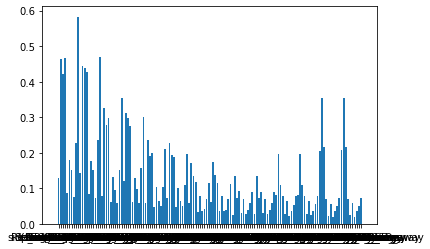

In [200]:
plt.bar(x=old_traindata.columns, height=X_norm.var())

<ipython-input-202-78dcb38a0235>:13: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  bar = ax.barh(cols, width=X_norm[cols].var(), height=0.75,color=[colors[b] for b in mask_new_feat[:n_cols]])
<ipython-input-202-78dcb38a0235>:25: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  bar = ax.barh(cols, width=X_norm[cols].var(), height=0.75,color=[colors[b] for b in mask_new_feat[n_cols:]])
<ipython-input-202-78dcb38a0235>:37: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


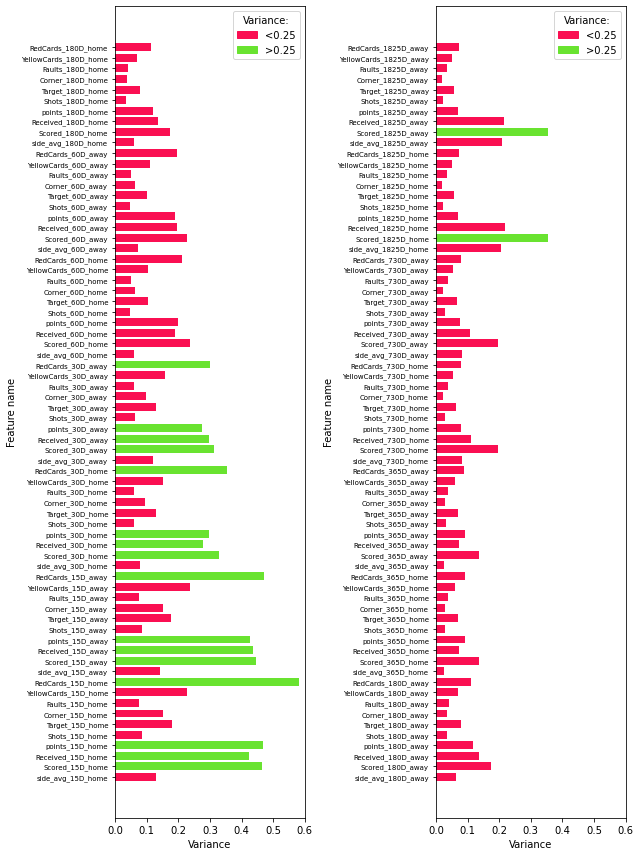

In [202]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(9,12))
plt.clf()
colors = ['#FA0F52','#69E330']
labels=['<0.25','>0.25']

n_cols = int(len(old_traindata.columns)/2)
cols = old_traindata.columns[:n_cols]

ax = fig.add_subplot(1,2,1)
bar = ax.barh(cols, width=X_norm[cols].var(), height=0.75,color=[colors[b] for b in mask_new_feat[:n_cols]])
# plt.title("Normalized feature variances")
# plt.suptitle("Normalized feature variances",fontsize=15)
artists  = [mpatches.Patch(color=c,label=l) for c,l in zip(colors,labels)]
ax.legend(handles=artists,title='Variance:',)
ax.set_ylabel("Feature name")
ax.set_xlabel("Variance")
ax.set_xlim(0,.6)
plt.yticks(fontsize=7)

cols = old_traindata.columns[n_cols:]
ax = fig.add_subplot(1,2,2)
bar = ax.barh(cols, width=X_norm[cols].var(), height=0.75,color=[colors[b] for b in mask_new_feat[n_cols:]])
# plt.title("Normalized feature variances")
# plt.suptitle("Normalized feature variances",fontsize=15)
artists  = [mpatches.Patch(color=c,label=l) for c,l in zip(colors,labels)]
ax.legend(handles=artists,title='Variance:',)
ax.set_ylabel("Feature name")
ax.set_xlabel("Variance")
ax.set_xlim(0,.6)
plt.yticks(fontsize=7)

fig.tight_layout()
fig.savefig(path_eda + 'divmean_feature_variances_historical.jpg', format='jpg', dpi=200,bbox_inches='tight')
fig.show()

#### ANOVA

In [186]:
traindata = ml.FootballMatchesDataset(dataset='historical_longterm',file='train')
# traindata = pd.DataFrame(data=traindata.data.cpu().numpy(),columns=traindata.features)
traindata.data

tensor([[ 2.0000,  0.0000,  3.0000,  ..., 12.8000,  1.4667,  0.8667],
        [ 2.0000,  2.0000,  4.0000,  ..., 12.8000,  1.6000,  0.8000],
        [ 2.0000,  4.0000,  2.0000,  ..., 13.5333,  2.2000,  1.0667],
        ...,
        [ 1.0000,  3.0000,  1.0000,  ..., 14.2185,  2.2914,  1.1854],
        [ 1.0000,  3.0000,  3.0000,  ..., 13.4762,  2.0741,  1.0317],
        [ 1.0000,  2.0000,  4.0000,  ..., 14.9365,  2.3280,  1.0317]],
       device='cuda:0', dtype=torch.float64)

In [187]:
train_data = pd.DataFrame(data=traindata.data.cpu().numpy(),columns=traindata.features)
old_traindata = train_data.copy()

X_mean = old_traindata.mean(axis=0)#.to_numpy()
X_norm = old_traindata / X_mean
X_norm

,side_avg_15D_home,Scored_15D_home,Received_15D_home,points_15D_home,Shots_15D_home,Target_15D_home,Corner_15D_home,Faults_15D_home,YellowCards_15D_home,RedCards_15D_home,...,side_avg_1825D_away,Scored_1825D_away,Received_1825D_away,points_1825D_away,Shots_1825D_away,Target_1825D_away,Corner_1825D_away,Faults_1825D_away,YellowCards_1825D_away,RedCards_1825D_away
0,1.589867,0.000000,0.996321,0.000000,0.531568,0.535884,0.890367,1.174583,1.946628,0.000000,...,0.108582,0.115033,0.163683,0.808275,0.903035,1.075228,1.289315,0.851993,0.731815,0.870911
1,1.589867,0.681054,1.328428,0.371051,0.654238,0.964591,0.791437,1.243676,0.729985,0.000000,...,0.108582,0.076688,0.181870,0.570547,0.630521,0.771959,0.850948,0.851993,0.798344,0.803918
2,1.589867,1.362109,0.664214,2.226303,0.858687,0.857414,0.989296,0.587292,0.729985,0.000000,...,0.108582,0.098599,0.187932,0.475456,0.694642,0.799529,0.876734,0.900805,1.097723,1.071890
3,1.589867,0.681054,1.328428,0.000000,0.899577,1.393297,1.582874,0.967304,0.973314,0.000000,...,0.108582,0.115033,0.127309,0.998457,0.721359,1.130368,1.134597,0.807618,0.632022,0.669932
4,1.589867,1.362109,0.664214,2.226303,0.736018,1.178944,1.187155,1.001850,0.729985,0.000000,...,0.108582,0.104077,0.157620,0.523001,0.732046,0.992518,0.889627,0.874180,1.064458,1.071890
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13896,0.794933,1.362109,0.664214,2.226303,0.981357,1.071767,1.483944,1.001850,2.189956,2.752975,...,0.279211,0.180766,0.503173,0.404780,0.983474,0.810333,0.841539,0.865305,1.051872,1.167854
13897,0.794933,1.362109,0.664214,1.484202,1.472035,1.500474,1.582874,0.552745,0.729985,0.550595,...,0.573934,0.399875,0.739603,0.656129,0.821815,0.719576,0.727174,0.958492,1.017888,0.964701
13898,0.794933,1.021582,0.332107,1.484202,0.899577,0.643060,0.791437,0.863664,0.973314,1.101190,...,1.163379,0.953127,1.648951,0.722630,0.910855,0.765477,0.908070,0.946414,1.143323,1.191236
13899,0.794933,1.021582,0.996321,0.742101,1.267586,0.964591,1.483944,0.760024,1.459971,1.651785,...,1.458102,1.676189,1.224589,1.181092,1.214987,1.032779,1.331269,0.897001,1.034890,1.036799


In [192]:
filter          = SelectKBest(score_func=f_classif,k=50)
filter.fit(X_norm,traindata.labels.argmax(dim=1))
mask_new_feat   = filter.get_support()
features        = old_traindata.columns[mask_new_feat]
train_data      = old_traindata[features]
pvalues = filter.pvalues_
train_data

,points_30D_home,Shots_30D_away,Scored_60D_home,points_60D_home,Shots_60D_home,Target_60D_home,Scored_60D_away,points_60D_away,Shots_60D_away,Target_60D_away,...,Scored_1825D_home,points_1825D_home,Shots_1825D_home,Target_1825D_home,Corner_1825D_home,Scored_1825D_away,points_1825D_away,Shots_1825D_away,Target_1825D_away,Corner_1825D_away
0,1.00,9.25,9.0,1.857143,12.857143,7.285714,10.0,1.142857,10.714286,4.571429,...,23.0,1.866667,13.666667,7.800000,7.266667,21.0,1.133333,11.266667,5.200000,6.666667
1,0.25,9.00,3.0,0.285714,9.571429,4.857143,6.0,0.571429,7.000000,3.714286,...,7.0,0.533333,9.066667,4.533333,4.666667,14.0,0.800000,7.866667,3.733333,4.400000
2,2.25,7.75,12.0,2.285714,14.428571,6.857143,4.0,0.714286,7.428571,2.285714,...,23.0,1.800000,13.533333,6.266667,4.800000,18.0,0.666667,8.666667,3.866667,4.533333
3,0.75,9.50,17.0,1.714286,15.000000,9.142857,7.0,1.285714,8.571429,4.714286,...,29.0,1.600000,12.666667,7.133333,6.666667,21.0,1.400000,9.000000,5.466667,5.866667
4,2.50,8.50,11.0,2.000000,10.714286,5.285714,5.0,0.142857,8.142857,4.000000,...,21.0,1.400000,12.600000,6.400000,6.266667,19.0,0.733333,9.133333,4.800000,4.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13896,1.50,10.75,10.0,1.333333,8.666667,3.333333,14.0,1.222222,12.111111,4.777778,...,183.0,1.105820,11.000000,3.497354,4.248677,33.0,0.567568,12.270270,3.918919,4.351351
13897,1.75,10.25,12.0,1.875000,16.000000,6.000000,12.0,1.222222,9.333333,3.111111,...,396.0,2.100529,16.708995,6.407407,6.142857,73.0,0.920000,10.253333,3.480000,3.760000
13898,1.75,10.75,17.0,2.125000,11.250000,3.500000,4.0,0.333333,9.111111,2.111111,...,387.0,2.457447,15.452128,5.590426,5.558511,174.0,1.013245,11.364238,3.701987,4.695364
13899,2.00,15.75,20.0,2.250000,15.875000,6.375000,16.0,1.555556,16.111111,6.111111,...,338.0,1.698413,14.375661,5.121693,5.756614,306.0,1.656085,15.158730,4.994709,6.883598


In [193]:
pval = pd.DataFrame(filter.pvalues_.reshape(1,-1), columns=old_traindata.columns)
pvalues = -np.log10(pval)
pvalues /= pvalues.max().max()
pvalues

,side_avg_15D_home,Scored_15D_home,Received_15D_home,points_15D_home,Shots_15D_home,Target_15D_home,Corner_15D_home,Faults_15D_home,YellowCards_15D_home,RedCards_15D_home,...,side_avg_1825D_away,Scored_1825D_away,Received_1825D_away,points_1825D_away,Shots_1825D_away,Target_1825D_away,Corner_1825D_away,Faults_1825D_away,YellowCards_1825D_away,RedCards_1825D_away
0,0.003875,0.202511,0.053287,0.190937,0.225269,0.234678,0.11288,0.01573,0.008549,0.015345,...,0.179129,0.624886,0.005331,0.975912,0.753017,0.548071,0.592147,0.070809,0.070755,0.122406


In [194]:
pvalues[cols].T[0]

side_avg_180D_away        0.000023
Scored_180D_away          0.579552
Received_180D_away        0.283123
points_180D_away          0.799805
Shots_180D_away           0.611878
                            ...   
Target_1825D_away         0.548071
Corner_1825D_away         0.592147
Faults_1825D_away         0.070809
YellowCards_1825D_away    0.070755
RedCards_1825D_away       0.122406
Name: 0, Length: 70, dtype: float64

Index(['points_30D_home', 'Shots_30D_away', 'Scored_60D_home',
       'points_60D_home', 'Shots_60D_home', 'Target_60D_home',
       'Scored_60D_away', 'points_60D_away', 'Shots_60D_away',
       'Target_60D_away', 'Scored_180D_home', 'points_180D_home',
       'Shots_180D_home', 'Target_180D_home', 'Corner_180D_home'],
      dtype='object')
Index(['points_30D_home', 'Shots_30D_away', 'Scored_60D_home',
       'points_60D_home', 'Shots_60D_home', 'Target_60D_home',
       'Scored_60D_away', 'points_60D_away', 'Shots_60D_away',
       'Target_60D_away', 'Scored_180D_home', 'points_180D_home',
       'Shots_180D_home', 'Target_180D_home', 'Corner_180D_home'],
      dtype='object')


<ipython-input-195-a747d589ea36>:38: UserWarning: Matplotlib is currently using module://ipykernel.pylab.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


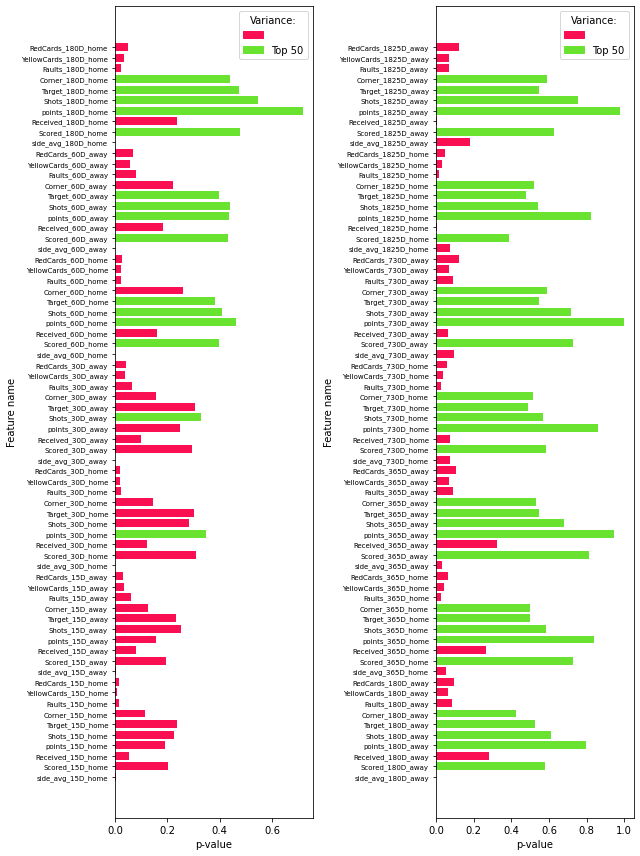

In [195]:
# pvalues = -np.log10(filter.pvalues_)
# pvalues /= pvalues.max()

fig = plt.figure(figsize=(9,12))
plt.clf()
colors = ['#FA0F52','#69E330']
labels=["","Top 50"]

n_cols = int(len(old_traindata.columns)/2)
cols = old_traindata.columns[:n_cols]
print(cols[mask_new_feat[:n_cols]])
ax = fig.add_subplot(1,2,1)
bar = ax.barh(cols, width=pvalues[cols].T[0], height=0.75,color=[(colors[int(b)]) for b in mask_new_feat[:n_cols]])
# plt.title("Normalized feature variances")
# plt.suptitle("Normalized feature variances",fontsize=15)
artists  = [mpatches.Patch(color=c,label=l) for c,l in zip(colors,labels)]
ax.legend(handles=artists,title='Variance:',)
ax.set_ylabel("Feature name")
ax.set_xlabel("p-value")
ax.set_xlim(0)
plt.yticks(fontsize=7)

print(cols[mask_new_feat[:n_cols]])
cols = old_traindata.columns[n_cols:]
ax = fig.add_subplot(1,2,2)
bar = ax.barh(cols, width=pvalues[cols].T[0], height=0.75,color=[colors[int(b)] for b in mask_new_feat[n_cols:]])
# plt.title("Normalized feature variances")
# plt.suptitle("Normalized feature variances",fontsize=15)
artists  = [mpatches.Patch(color=c,label=l) for c,l in zip(colors,labels)]
ax.legend(handles=artists,title='Variance:',)
ax.set_ylabel("Feature name")
ax.set_xlabel("p-value")
ax.set_xlim(0)
plt.yticks(fontsize=7)

fig.tight_layout()
fig.savefig(path_eda + 'divmean_anova_historical.jpg', format='jpg', dpi=200,bbox_inches='tight')
fig.show()

#### BONUS PLOT

In [7]:
path_logs = 'F:\\TFG\\results\\logs\\'

def plot_biasvariance(logs,ax):
    trainerror = logs.trainloss.iloc[-1]
    testerror  = logs.testloss.iloc[-1]
    biasvariance = [trainerror, testerror-trainerror]
    ax.bar([1,2], biasvariance, color=['#5EB8DB','#FCAA19'])
    plt.xticks([1,2],['bias (underfitting)','variance (overfitting)'],fontsize=10)

def plot_error(logs,path_exec,fld='',title='',display=False):
    plt.figure(2,figsize=(6,4))
    if title=='': title = f'error_{fld}'
    labels = ['Train Loss','Test Loss']
    for log,label in zip(logs,labels):
        plt.plot(log,label=label)
    # for it in range(5):
    #     data = trainlogs[trainlogs.it==it]
    #     plt.plot(data.trainloss,label=it+1)
    # plt.plot(trainlogs.loss)
    plt.title(f'Error plot')
    plt.xticks(range(0,len(logs[0])+1,int(len(logs[0])/10)),rotation=45)
    plt.legend()
    # plt.grid()
    plt.xlabel('epochs')
    plt.ylabel('error')
    plt.ylim(0)
    plt.tight_layout()
    plt.savefig(path_exec + title + '.jpg', format='jpg', dpi=200)
    print(path_exec + title + '.jpg')
    if display: plt.show()

def plot_accuracy(logs,path_exec,fld='',title='',display=False):
    plt.figure(2,figsize=(6,4))
    if title=='': title = f'accuracy_{fld}'
    labels = ['Train Accuracy','Test Accuracy']
    for log,label in zip(logs,labels):
        plt.plot(log,label=label)
    # for it in range(5):
    #     data = trainlogs[trainlogs.it==it]
    #     plt.plot(data.trainloss,label=it+1)
    # plt.plot(trainlogs.loss)
    plt.title(f'Accuracy plot')
    plt.xticks(range(0,len(logs[0])+1,int(len(logs[0])/10)),rotation=45)
    plt.legend()
    # plt.grid()
    plt.xlabel('epochs')
    plt.ylabel('accuracy')
    plt.ylim(0)
    plt.tight_layout()
    plt.savefig(path_exec + title + '.jpg', format='jpg', dpi=200)
    print(path_exec + title + '.jpg')
    if display: plt.show()

def plot_error_ax(logs,ax,labels,title="", lim=True):
    for log,label in zip(logs,labels):
        ax.plot(log,label=label)
    ax.set_title(title)
    plt.xticks(range(0,len(logs[0])+1,int(len(logs[0])/10)),rotation=45)
    # ax.legend()
    # plt.grid()
    ax.set_xlabel('epochs')
    ax.set_ylabel('error')
    if lim: ax.set_ylim(0)
    plt.tight_layout()

def plot_accuracy_ax(logs,ax,labels,title="",lim=True):
    for log,label in zip(logs,labels):
        ax.plot(log,label=label)
    ax.set_title(title)
    plt.xticks(range(0,len(logs[0])+1,int(len(logs[0])/10)),rotation=45)
    # ax.legend()
    # plt.grid()
    ax.set_xlabel('epochs')
    ax.set_ylabel('accuracy')
    if lim: ax.set_ylim(0,1)
    plt.tight_layout()

# plt.savefig(path_exec + title + '.jpg', format='jpg', dpi=200)


In [2]:
title = "rs_wysc_basic_lw1"

In [115]:
# title = 'nndo_4layers_10163params_dropout0.25'
import json
path_logs = 'F:\\TFG\\results\\logs\\'

with open(path_logs+'cdsm_32batch_443params'+'.json') as wg:
    weights_grads = json.load(wg)

In [125]:
logs = pd.read_csv(path_logs+title+'_logs.csv',sep=';')


KeyError: 'trainloss'

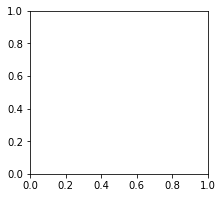

In [144]:
fig = plt.figure(figsize=(7,3))
ax = fig.add_subplot(1,2,1)
plot_error_ax([logs['trainloss'],logs['testloss']],ax,['Train','Test'],"Error",lim=False)
ax = fig.add_subplot(1,2,2)
plot_error_ax([logs['acc_train'],logs['acc_test']],ax,['Train','Test'],"Accuracy")
fig.savefig(path_graphs+"m0_wyscout\\" + title + '.jpg', format='jpg', dpi=200, bbox_inches='tight')


##### Performance architectures

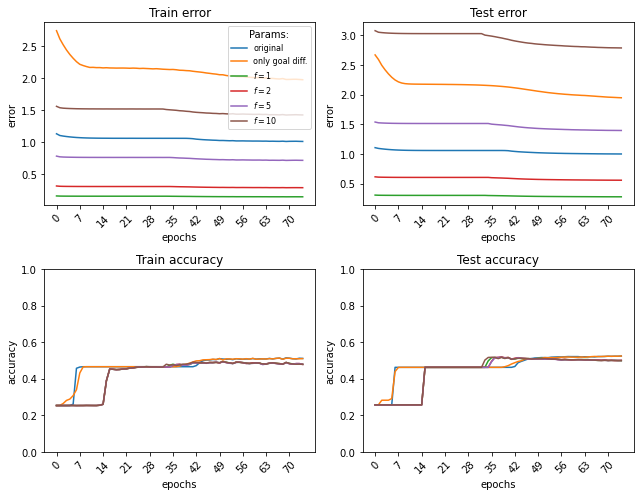

In [21]:
path_logs = 'F:\\TFG\\experiments\\logs\\'

fig = plt.figure(figsize=(9,7))
list_execs = ["hl_fno","hl_f0","hl_f1","hl_f2","hl_f5","hl_f10"]
labels = ['original','only goal diff.','$f = 1$','$f = 2$','$f = 5$','$f = 10$']
logs = { k:pd.read_csv(path_logs+ k + '\\' + k +'_0_logs.csv',sep=';',decimal=',') for k in list_execs }

ax = fig.add_subplot(2,2,1)
plot_error_ax([ logs[k]['trainloss'] for k in list_execs ],ax,labels,"Train error",lim=False)
ax.legend(title='Params:',prop={"size":8})
ax = fig.add_subplot(2,2,2)
plot_error_ax([ logs[k]['testloss'] for k in list_execs ],ax,labels,"Test error",lim=False)
# ax.legend(title='Params:',prop={"size":7})
ax = fig.add_subplot(2,2,3)
plot_accuracy_ax([ logs[k]['acc_train'] for k in list_execs ],ax,labels,"Train accuracy",lim=True)
ax = fig.add_subplot(2,2,4)
plot_accuracy_ax([ logs[k]['acc_test'] for k in list_execs ],ax,labels,"Test accuracy",lim=True)


fig.savefig(path_graphs+"m0_wyscout\\" + "metrics_factor_lt_137" + '.jpg', format='jpg', dpi=200, bbox_inches='tight')

##### Batch-Normalization effects

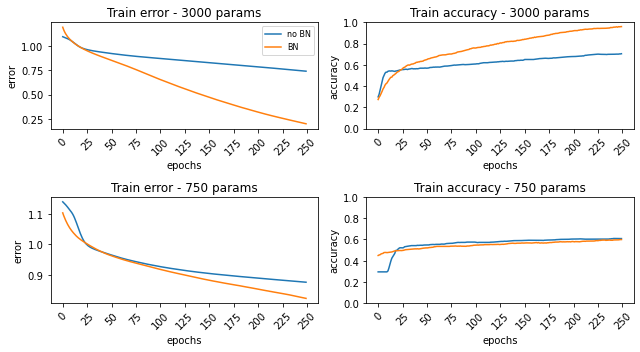

In [35]:
fig = plt.figure(figsize=(9,5))
list_execs = ["cdsm_4layers_3023params","nnbn_4layers_3103params"]

logs = { k:pd.read_csv(path_logs+ k +'_logs.csv',sep=';') for k in list_execs }

ax = fig.add_subplot(2,2,1)
plot_error_ax([ logs[k]['trainloss'] for k in list_execs ],ax,["no BN","BN"],"Train error - 3000 params",lim=False)
ax.legend(prop={"size":8})

ax = fig.add_subplot(2,2,2)
plot_accuracy_ax([ logs[k]['acc_train'] for k in list_execs ],ax,["no BN","BN"],"Train accuracy - 3000 params",lim=True)

list_execs = ["cdsm_32batch_743params","nnbn_4layers_773params"]
logs = { k:pd.read_csv(path_logs+ k +'_logs.csv',sep=';') for k in list_execs }

ax = fig.add_subplot(2,2,3)
plot_error_ax([ logs[k]['trainloss'] for k in list_execs ],ax,["no BN","BN"],"Train error - 750 params",lim=False)

ax = fig.add_subplot(2,2,4)
plot_accuracy_ax([ logs[k]['acc_train'] for k in list_execs ],ax,["no BN","BN"],"Train accuracy - 750 params",lim=True)

fig.savefig(path_graphs+"m0_wyscout\\" + "error_wyscout_bn" + '.jpg', format='jpg', dpi=200, bbox_inches='tight')

No handles with labels found to put in legend.


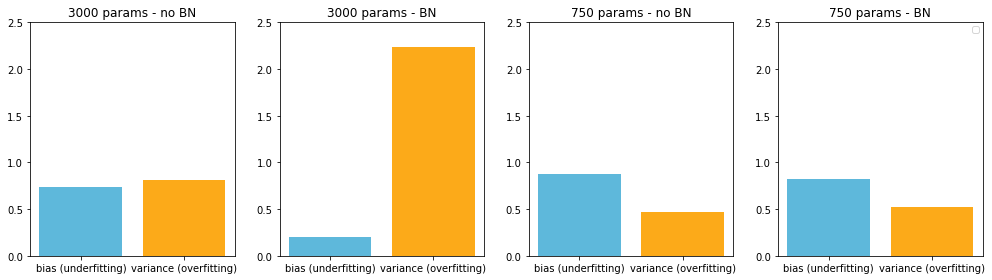

In [47]:
fig = plt.figure(figsize=(14,4))

list_execs = ["cdsm_4layers_3023params","nnbn_4layers_3103params","cdsm_32batch_743params","nnbn_4layers_773params"]
title = ["3000 params - no BN", "3000 params - BN", "750 params - no BN", "750 params - BN", ]

for i,exec in enumerate(list_execs):
    logs = pd.read_csv(path_logs+ exec +'_logs.csv',sep=';')
    ax = fig.add_subplot(1,4,i+1)
    ax.set_title(title[i])
    ax.set_ylim(0,2.5)
    plot_biasvariance(logs,ax)

plt.legend(prop={"size":8})
fig.tight_layout()
fig.savefig(path_graphs+"m0_wyscout\\" + "biasvariance_wyscout_bn" + '.jpg', format='jpg', dpi=200, bbox_inches='tight')

##### Weight decay

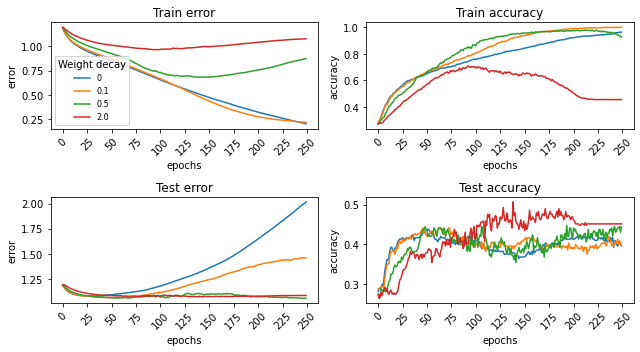

In [11]:
fig = plt.figure(figsize=(9,5))
list_execs = ["wysc_3000_bnnn","wysc_3000_bnnn_wd0.1","wysc_3000_bnnn_wd0.5","wysc_3000_bnnn_wd2.0"]
path_logs = "F:\\TFG\\experiments\\logs\\"

logs = { k:pd.read_csv(path_logs+ k + '\\' + k +'_0_logs.csv',sep=';',decimal=',') for k in list_execs }

ax = fig.add_subplot(2,2,1)
plot_error_ax([ logs[k]['trainloss'] for k in list_execs ],ax,[0,0.1,0.5,2.0],"Train error",lim=False)
ax.legend(title='Weight decay',prop={"size":8})

ax = fig.add_subplot(2,2,2)
plot_accuracy_ax([ logs[k]['acc_train'] for k in list_execs ],ax,[0,0.1,0.5,2.0],"Train accuracy",lim=0)

ax = fig.add_subplot(2,2,3)
plot_error_ax([ logs[k]['testloss'] for k in list_execs ],ax,[0,0.1,0.5,2.0],"Test error",lim=False)

ax = fig.add_subplot(2,2,4)
plot_accuracy_ax([ logs[k]['acc_test'] for k in list_execs ],ax,[0,0.1,0.5,2.0],"Test accuracy",lim=0)

fig.savefig(path_graphs+"m3_wyscout\\" + "error_wyscout_bn_wd" + '.jpg', format='jpg', dpi=200, bbox_inches='tight')

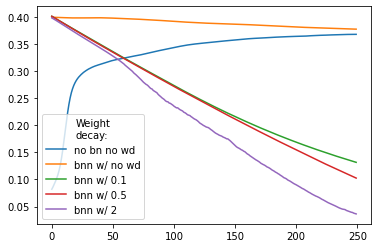

In [122]:
type = 'activations'
layer = 'h2'
plt.figure(figsize=(6,4))
grads = torch.load(path_logs+"wysc_3000_dump" + f"\\{type}\\" + f"{layer}" + "_out.pt")
plt.plot(grads.numpy(), label='no bn no wd')
grads = torch.load(path_logs+"wysc_3000_bnnn" + f"\\{type}\\" + f"{layer}" + "_out.pt")
plt.plot(grads.numpy(), label='bnn w/ no wd')
grads = torch.load(path_logs+"wysc_3000_bnnn_wd0.1" + f"\\{type}\\" + "h1" + "_out.pt")
plt.plot(grads.numpy(), label='bnn w/ 0.1')
grads = torch.load(path_logs+"wysc_3000_bnnn_wd0.5" + f"\\{type}\\" + "h1" + "_out.pt")
plt.plot(grads.numpy(), label='bnn w/ 0.5')
grads = torch.load(path_logs+"wysc_3000_bnnn_wd2.0" + f"\\{type}\\" + f"{layer}" + "_out.pt")
plt.plot(grads.numpy(), label='bnn w/ 2')

plt.legend(title='Weight\ndecay:')
plt.savefig(path_graphs+"m3_wyscout\\" + "activ_wysc_wd" + '.jpg', format='jpg', dpi=200, bbox_inches='tight')

##### Drop-Out

INFO: imported
INFO: plot 1


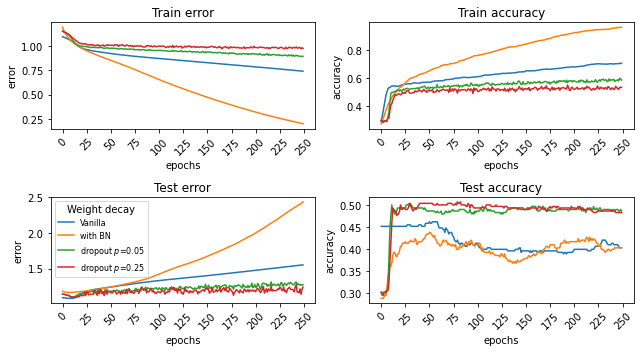

In [12]:
fig = plt.figure(figsize=(9,5))
list_execs = ["cdsm_4layers_3023params","nnbn_4layers_3103params","nndo_4layers_2923params_dropout0.05","nndo_4layers_2923params_dropout0.25"]
path_logs = "F:\\TFG\\results\\logs\\"
labels = ["Vanilla","with BN","dropout $p$=0.05","dropout $p$=0.25",]

logs = { k:pd.read_csv(path_logs+ k +'_logs.csv',sep=';') for k in list_execs }
print('INFO: imported')

ax = fig.add_subplot(2,2,1)
plot_error_ax([ logs[k]['trainloss'] for k in list_execs ],ax,labels,"Train error",lim=False)
print('INFO: plot 1')

ax = fig.add_subplot(2,2,2)
plot_accuracy_ax([ logs[k]['acc_train'] for k in list_execs ],ax,labels,"Train accuracy",lim=False)

ax = fig.add_subplot(2,2,3)
plot_error_ax([ logs[k]['testloss'] for k in list_execs ],ax,labels,"Test error",lim=False)
ax.legend(title='Weight decay',prop={"size":8})

ax = fig.add_subplot(2,2,4)
plot_accuracy_ax([ logs[k]['acc_test'] for k in list_execs ],ax,labels,"Test accuracy",lim=False)

fig.savefig(path_graphs+"m3_wyscout\\" + "error_wyscout_dropout" + '.jpg', format='jpg', dpi=200, bbox_inches='tight')

No handles with labels found to put in legend.


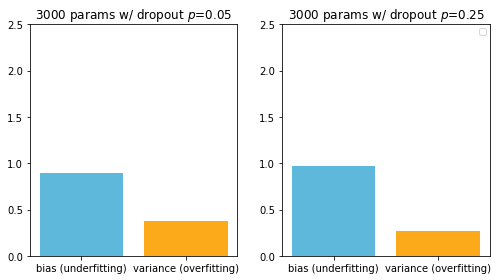

In [17]:
fig = plt.figure(figsize=(14,4))

list_execs = ["nndo_4layers_2923params_dropout0.05","nndo_4layers_2923params_dropout0.25"]
title = ["3000 params w/ dropout $p$=0.05","3000 params w/ dropout $p$=0.25",]

for i,exec in enumerate(list_execs):
    logs = pd.read_csv(path_logs+ exec +'_logs.csv',sep=';')
    ax = fig.add_subplot(1,4,i+1)
    ax.set_title(title[i])
    ax.set_ylim(0,2.5)
    plot_biasvariance(logs,ax)

plt.legend(prop={"size":8})
fig.tight_layout()
fig.savefig(path_graphs+"m3_wyscout\\" + "biasvariance_wyscout_dropout" + '.jpg', format='jpg', dpi=200, bbox_inches='tight')

##### Gradients

In [51]:
grads

tensor([-1.1445e-11, -5.7224e-12,  5.4363e-11,  0.0000e+00,  0.0000e+00,
        -1.7167e-11,  1.1445e-11,  2.0028e-11,  5.7224e-12,  1.0586e-10,
        -1.1445e-11, -2.5751e-11,  2.8612e-11,  8.5836e-12,  3.4334e-11,
         1.7167e-11, -5.1502e-11,  7.1530e-11, -2.0028e-11,  2.2890e-11,
        -4.0057e-11,  2.2890e-11,  4.0057e-11, -2.8612e-11, -8.5836e-11,
        -1.7167e-11,  1.4306e-11, -5.1502e-11, -5.7224e-12,  5.1502e-11,
         9.1559e-11, -1.4306e-11, -2.8612e-11, -2.8612e-12,  5.7224e-12,
         2.8612e-12,  2.8612e-12, -8.5836e-12, -8.5836e-12,  5.7224e-12,
        -1.4306e-12,  0.0000e+00,  1.7167e-11, -1.4306e-12, -8.5836e-12,
         1.4306e-11,  8.5836e-12,  3.1473e-11,  2.8612e-12, -1.1445e-11,
        -1.1445e-11,  1.4306e-11,  5.7224e-12, -2.8612e-12, -2.0028e-11,
         1.1445e-11, -3.4334e-11, -4.2918e-12, -2.8612e-12,  2.0028e-11,
         5.7224e-12, -8.5836e-12, -2.8612e-12, -5.7224e-12,  8.5836e-12,
        -8.5836e-12,  8.5836e-12,  8.5836e-12,  2.8

Text(0.5, 0, 'Epochs')

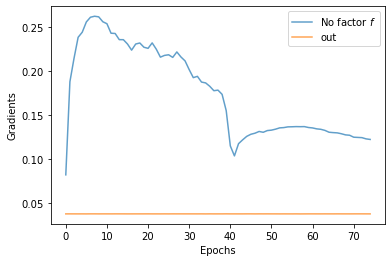

In [66]:
path_logs = 'F:\\TFG\\experiments\\logs\\'

type = 'activations'
layer = 'input'
plt.figure(figsize=(6,4))

# ["hl_fno","hl_f0","hl_f1","hl_f2","hl_f5","hl_f10"]


grads = torch.load(path_logs+"hl_fno" + f"\\{type}\\" + f"h1" + "_in.pt")
plt.plot(grads.numpy(), alpha=.7, label='No factor $f$')
grads = torch.load(path_logs+"hl_fno" + f"\\{type}\\" + f"{layer}" + "_out.pt")
plt.plot(grads.numpy(), alpha=.7, label='out')

# grads = torch.load(path_logs+"hl_f1" + f"\\{type}\\" + f"{layer}" + "_in.pt")
# plt.plot(grads.numpy(), alpha=1, label='$f = 2$')
# grads = torch.load(path_logs+"hl_f10" + f"\\{type}\\" + f"{layer}" + "_in.pt")
# plt.plot(grads.numpy(), alpha=.3, label='$f = 10$')
# grads = torch.load(path_logs+"hl_f0" + f"\\{type}\\" + f"{layer}" + "_out.pt")
# plt.plot(grads.numpy(), alpha=.4, label='only goal diff.')


# grads = torch.load(path_logs+"wysc_3000_bnnn_wd0.1" + f"\\{type}\\" + "h1" + "_out.pt")
# plt.plot(grads.numpy(), label='bnn w/ 0.1')
# grads = torch.load(path_logs+"wysc_3000_bnnn_wd0.5" + f"\\{type}\\" + "h1" + "_out.pt")
# plt.plot(grads.numpy(), label='bnn w/ 0.5')
# grads = torch.load(path_logs+"wysc_3000_bnnn_wd2.0" + f"\\{type}\\" + f"{layer}" + "_out.pt")
# plt.plot(grads.numpy(), label='bnn w/ 2')

plt.legend()
plt.ylabel("Gradients")
plt.xlabel("Epochs")
# plt.savefig(path_graphs+"summary\\" + "grads_factor_output" + '.jpg', format='jpg', dpi=200, bbox_inches='tight')

##### other

F://TFG//graphs//overfitting_batch_wyscout\error_overfitting_263.jpg


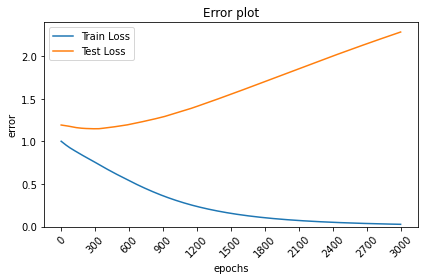

F://TFG//graphs//overfitting_batch_wyscout\accuracy_overfitting_263.jpg


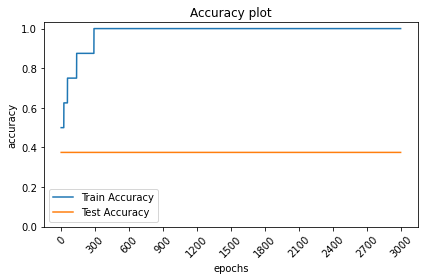

In [44]:
plot_error([weights_grads['train']['trainloss'],weights_grads['test']['testloss']],path_exec=path_graphs+"overfitting_batch_wyscout\\",fld='overfitting_263',display=True)
plot_accuracy([weights_grads['train']['acc'],weights_grads['test']['acc']],path_exec=path_graphs+"overfitting_batch_wyscout\\",fld='overfitting_263',display=True)

In [44]:
train_error_3l = [0.89,0.85,0.85,0.83,0.8,0.76,0.67,0.52]
train_error_4l = list(map(float,"0,89 0,85 0,87 0,82 0,8 0,74 0,68 0,37".replace(",",".").split(" ")))
train_error_10l = list(map(float,"1,07 0,86 0.9 0.9 0,89 0,75 0.75 0,7".replace(",",".").split(" ")))
train_error_20l = list(map(float,"1.06 0,89 0.91 0.9 0,85 0,72 0.7 0,62".replace(",",".").split(" ")))

train_error = pd.DataFrame({
        "params":[500,750,1000,1500,2000,3000,5000,10000],
        3:train_error_3l, 
        4:train_error_4l, 
        10:train_error_10l, 
        20:train_error_20l
    }, dtype=float)


test_error_3l = list(map(float,"1,33 1,39 1,37 1,38 1,4 1,5 1,57 1,78".replace(",",".").split(" ")))
test_error_4l = list(map(float,"1,32 1,39 1,36 1,44 1,44 1,55 1,64 2,49".replace(",",".").split(" ")))
test_error_10l = list(map(float,"1,07 1.32 1,3 1.29 1,3 1.71 1,82 1,82".replace(",",".").split(" ")))
test_error_20l = list(map(float,"1,07 1.31 1.31 1.33 1.4 1.88 1.07 2.15".replace(",",".").split(" ")))

test_error = pd.DataFrame({
        "params":[500,750,1000,1500,2000,3000,5000,10000],
        3:test_error_3l, 
        4:test_error_4l, 
        10:test_error_10l, 
        20:test_error_20l
    }, dtype=float)

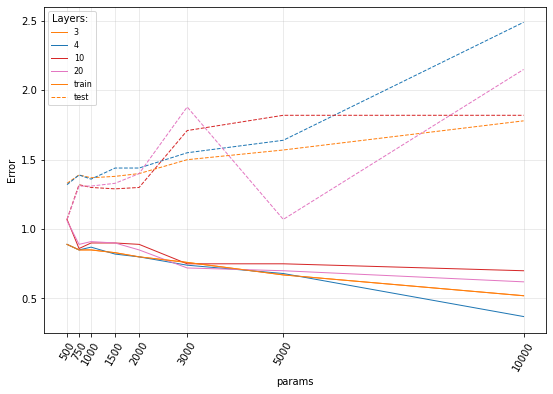

In [98]:
plt.figure(figsize=(9,6))

colors = ["tab:orange", "tab:blue", "tab:red", "tab:pink"]

sns.lineplot(data=train_error,x="params",y=3, linewidth=1,color=colors[0], label=3)
sns.lineplot(data=train_error,x="params",y=4, linewidth=1,color=colors[1], label=4)
sns.lineplot(data=train_error,x="params",y=10, linewidth=1,color=colors[2], label=10)
sns.lineplot(data=train_error,x="params",y=20, linewidth=1,color=colors[3], label=20)

sns.lineplot(data=train_error,x="params",y=3, linewidth=1,color=colors[0], label="train")
sns.lineplot(data=test_error,x="params",y=3, linestyle="--", linewidth=1,color=colors[0], label="test")
sns.lineplot(data=test_error,x="params",y=4, linestyle="--", linewidth=1,color=colors[1])
sns.lineplot(data=test_error,x="params",y=10, linestyle="--", linewidth=1,color=colors[2])
sns.lineplot(data=test_error,x="params",y=20, linestyle="--", linewidth=1,color=colors[3])

# h,l = plt.axes().get_legend_handles_labels()
# ph = [plt.plot([], marker="", ls="")[0]] * 3
# handles = [ plt.plot([], marker="", ls="")[0] , plt.plot([], marker="", ls="")[0], *h[:4], plt.plot([], marker="", ls="")[0], *h[4:] ]  # ph + h
# labels = ["Layers: ", "Train: ", *l[:4], "Test: ", *l[4:], ] #["Title 1:", "Title 2:"] + l

# plt.legend(handles, labels)
plt.legend(title="Layers: ", prop={'size':8})
plt.ylabel("Error")
plt.ylim(0.25,2.6)
plt.grid(alpha=.3)
plt.xticks(train_error.params,rotation=60)
plt.savefig(path_graphs + "m0_wyscout\\" + "exp_architecture_error" + '.jpg', format='jpg', dpi=200, bbox_inches='tight')
plt.show()

In [68]:
list(zip(handles,labels))

[(<matplotlib.lines.Line2D at 0x24eb54c18b0>, 'Layers: '),
 (<matplotlib.lines.Line2D at 0x24eb552cbb0>, 'Train: '),
 ('3', <matplotlib.lines.Line2D at 0x24eb4fa8ee0>),
 ('4', <matplotlib.lines.Line2D at 0x24eb4f6c8e0>),
 ('10', <matplotlib.lines.Line2D at 0x24eb4f6be20>),
 ('20', <matplotlib.lines.Line2D at 0x24eb4f8d100>),
 (<matplotlib.lines.Line2D at 0x24eb552ce80>, 'Test: '),
 ('3', <matplotlib.lines.Line2D at 0x24eb4f8cbb0>),
 ('4', <matplotlib.lines.Line2D at 0x24eb5292b50>),
 ('10', <matplotlib.lines.Line2D at 0x24eb4f8dbb0>),
 ('20', <matplotlib.lines.Line2D at 0x24eb4f6c9a0>)]